In [1]:
print("Cell running checking...\n Successful")

Cell running checking...
 Successful


In [2]:
# ================================
# Cell 1: Imports & Utility Functions for MobileViT-S
# Model: MobileViT-S (Small variant)
# Purpose: Import libraries and define helper functions
# Runtime: ~5-10 seconds
# ================================

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Core libraries
import os
import cv2
import numpy as np
from tqdm import tqdm
import time

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# MobileViT model
import timm

# Metrics & Visualization
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("🚀 MobileViT-S LIVER TUMOR CLASSIFICATION")
print("="*60)
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print("="*60)


# ================================
# Compute Metrics Function
# ================================
def compute_metrics(y_true, y_pred):
    """
    Calculate comprehensive classification metrics
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
    
    Returns:
        Dictionary with accuracy, precision, recall, F1, confusion matrix
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'confusion_matrix': cm
    }


# ================================
# Custom Dataset for Liver Slices
# ================================
class LiverSliceDataset(Dataset):
    """
    PyTorch Dataset for liver tumor binary classification
    Loads images on-the-fly to optimize memory usage
    """
    def __init__(self, image_dir, mask_dir, image_files, mask_files, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Resize to 256x256 (MobileViT standard input)
        img = cv2.resize(img, (256, 256))
        img = img.astype("float32") / 255.0
        
        # Convert grayscale to 3-channel (RGB format)
        img = np.repeat(img[..., None], 3, axis=2)  # HWC format

        # Load mask and create binary label
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Binary classification: 1 = tumor present, 0 = no tumor
        label = 1 if mask.sum() > 0 else 0

        # Convert to PyTorch tensor (CHW format)
        img = torch.tensor(img).permute(2, 0, 1)  # C, H, W
        label = torch.tensor(label, dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label


print("✓ Dataset class and utility functions defined!")
print("✓ Ready for data loading (Cell 2)")
print("="*60)

🚀 MobileViT-S LIVER TUMOR CLASSIFICATION
✓ PyTorch version: 2.6.0+cu124
✓ CUDA available: True
✓ GPU: Tesla P100-PCIE-16GB
✓ Dataset class and utility functions defined!
✓ Ready for data loading (Cell 2)


In [3]:
# ================================
# Cell 2: Data Loading & Preparation (MobileViT-S)
# Purpose: Load dataset, create stratified split, prepare DataLoaders
# Runtime: ~30-60 seconds
# ================================

print("📁 Loading dataset...")
print("="*60)

# Define directories
image_dir = "/kaggle/input/litsdataset2/images"
mask_dir = "/kaggle/input/litsdataset2/masks"

# Get sorted file lists
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

print(f"✓ Total images found: {len(image_files)}")
print(f"✓ Total masks found: {len(mask_files)}")

# Verify matching files
assert len(image_files) == len(mask_files), "❌ Mismatch between images and masks!"


# ================================
# Quick Label Extraction for Stratified Split
# ================================
def quick_label(mask_path):
    """Fast label extraction - checks if tumor exists in mask"""
    m = cv2.imread(mask_path, 0)
    m = cv2.resize(m, (256, 256), interpolation=cv2.INTER_NEAREST)
    return 1 if m.sum() > 0 else 0


print("\n🔍 Extracting labels for stratified split...")
labels = []
for mf in tqdm(mask_files, desc="📊 Labeling", ncols=80):
    labels.append(quick_label(os.path.join(mask_dir, mf)))

# Count distribution
tumor_count = sum(labels)
normal_count = len(labels) - tumor_count

print(f"\n📊 Dataset Distribution:")
print(f"   ├─ Tumor slices: {tumor_count} ({tumor_count/len(labels)*100:.1f}%)")
print(f"   ├─ Normal slices: {normal_count} ({normal_count/len(labels)*100:.1f}%)")
print(f"   └─ Total: {len(labels)}")

# Check class balance
if tumor_count < len(labels) * 0.1 or tumor_count > len(labels) * 0.9:
    print("⚠️  Warning: Imbalanced dataset detected!")


# ================================
# Stratified Train/Validation Split (80/20)
# ================================
print("\n✂️  Creating stratified train/val split (80/20)...")
img_train, img_val, mask_train, mask_val = train_test_split(
    image_files, mask_files, 
    test_size=0.20, 
    random_state=42, 
    stratify=labels
)

print(f"   ├─ Train slices: {len(img_train)}")
print(f"   └─ Val slices: {len(img_val)}")

# Verify stratification
train_labels = [quick_label(os.path.join(mask_dir, mf)) for mf in mask_train]
val_labels = [quick_label(os.path.join(mask_dir, mf)) for mf in mask_val]

train_tumor_pct = sum(train_labels) / len(train_labels) * 100
val_tumor_pct = sum(val_labels) / len(val_labels) * 100

print(f"\n✓ Stratification verified:")
print(f"   ├─ Train tumor %: {train_tumor_pct:.1f}%")
print(f"   └─ Val tumor %: {val_tumor_pct:.1f}%")


# ================================
# Create PyTorch Datasets
# ================================
print("\n🔄 Creating PyTorch Datasets...")
train_ds = LiverSliceDataset(image_dir, mask_dir, img_train, mask_train)
val_ds = LiverSliceDataset(image_dir, mask_dir, img_val, mask_val)

print(f"   ├─ Train dataset size: {len(train_ds)}")
print(f"   └─ Val dataset size: {len(val_ds)}")


# ================================
# Create DataLoaders
# ================================
batch_size = 16  # Adjust based on GPU memory
num_workers = 2

print(f"\n🚀 Creating DataLoaders (batch_size={batch_size})...")
train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers, 
    pin_memory=True,
    drop_last=True  # For stable batch normalization
)

val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers, 
    pin_memory=True
)

print(f"   ├─ Train batches per epoch: {len(train_loader)}")
print(f"   └─ Val batches per epoch: {len(val_loader)}")


# ================================
# Estimate Training Time
# ================================
samples_per_sec = 80  # Conservative estimate for MobileViT-S
train_time_estimate = (len(img_train) / samples_per_sec) / 60
val_time_estimate = (len(img_val) / samples_per_sec) / 60
total_time_per_epoch = train_time_estimate + val_time_estimate

print(f"\n⏱️  Estimated time per epoch:")
print(f"   ├─ Training: ~{train_time_estimate:.1f} minutes")
print(f"   ├─ Validation: ~{val_time_estimate:.1f} minutes")
print(f"   └─ Total: ~{total_time_per_epoch:.1f} minutes/epoch")

print("\n✅ Data preparation complete!")
print("="*60)
print("📝 Next: Run Cell 3 to start training")
print("="*60)

📁 Loading dataset...
✓ Total images found: 58638
✓ Total masks found: 58638

🔍 Extracting labels for stratified split...


📊 Labeling: 100%|███████████████████████| 58638/58638 [04:04<00:00, 239.85it/s]



📊 Dataset Distribution:
   ├─ Tumor slices: 19158 (32.7%)
   ├─ Normal slices: 39480 (67.3%)
   └─ Total: 58638

✂️  Creating stratified train/val split (80/20)...
   ├─ Train slices: 46910
   └─ Val slices: 11728

✓ Stratification verified:
   ├─ Train tumor %: 32.7%
   └─ Val tumor %: 32.7%

🔄 Creating PyTorch Datasets...
   ├─ Train dataset size: 46910
   └─ Val dataset size: 11728

🚀 Creating DataLoaders (batch_size=16)...
   ├─ Train batches per epoch: 2931
   └─ Val batches per epoch: 733

⏱️  Estimated time per epoch:
   ├─ Training: ~9.8 minutes
   ├─ Validation: ~2.4 minutes
   └─ Total: ~12.2 minutes/epoch

✅ Data preparation complete!
📝 Next: Run Cell 3 to start training


In [4]:
# ================================
# Cell 3: Training Loop - MobileViT-S (5 Epochs)
# Purpose: Train MobileViT-S model and track best performance
# Runtime: ~5-10 minutes per epoch (depends on GPU)
# ================================

print("="*60)
print("🚀 INITIALIZING MOBILEVIT-S TRAINING")
print("="*60)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


# ================================
# Model Initialization - MobileViT-S
# ================================
print("\n🏗️  Loading MobileViT-S model...")
model_name = "mobilevit_s"  # MobileViT-Small variant
try:
    model = timm.create_model(model_name, pretrained=True, num_classes=2)
    print(f"✓ Model: {model_name} loaded successfully")
except:
    print("⚠️  Model not found, trying alternative name...")
    model_name = "mobilevitv2_050"
    model = timm.create_model(model_name, pretrained=True, num_classes=2)
    print(f"✓ Model: {model_name} loaded successfully")

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   ├─ Total parameters: {total_params:,}")
print(f"   ├─ Trainable parameters: {trainable_params:,}")
print(f"   └─ Model size: ~{total_params * 4 / 1e6:.1f} MB")


# ================================
# Training Configuration
# ================================
print("\n⚙️  Training Configuration:")

# Loss function with class weights (if imbalanced)
criterion = nn.CrossEntropyLoss()

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler: Cosine annealing
num_epochs = 50  # Set to 5 for initial testing
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Mixed precision training (faster on modern GPUs)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# Save paths
save_path = "/kaggle/working/mobilevit_best.pth"

print(f"   ├─ Total epochs: {num_epochs}")
print(f"   ├─ Learning rate: 1e-4")
print(f"   ├─ Weight decay: 1e-4")
print(f"   ├─ Optimizer: AdamW")
print(f"   ├─ LR Scheduler: CosineAnnealingLR")
print(f"   └─ Mixed precision: {torch.cuda.is_available()}")


# ================================
# Tracking Variables
# ================================
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'learning_rates': []
}

best_val_f1 = 0.0
best_epoch = 0
best_metrics = None
best_val_probs = None
best_val_targets = None

print("\n" + "="*60)
print(f"🎯 STARTING TRAINING - {num_epochs} EPOCHS")
print("="*60)

training_start_time = time.time()


# ================================
# Main Training Loop
# ================================
for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()
    
    print(f"\n{'='*60}")
    print(f"📅 EPOCH {epoch}/{num_epochs}")
    print(f"{'='*60}")
    
    
    # ------------------------------------
    # TRAINING PHASE
    # ------------------------------------
    model.train()
    train_losses = []
    train_preds_all = []
    train_targets_all = []
    
    train_pbar = tqdm(train_loader, desc=f"🔥 Training", ncols=100, colour='green')
    
    for batch_idx, (imgs, labels) in enumerate(train_pbar):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        # Mixed precision forward pass
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Track metrics
        train_losses.append(loss.item())
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds_all.extend(preds)
        train_targets_all.extend(labels.cpu().numpy())
        
        # Update progress bar
        current_acc = accuracy_score(train_targets_all, train_preds_all)
        train_pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{current_acc:.4f}'
        })
    
    # Calculate training metrics
    train_acc = accuracy_score(train_targets_all, train_preds_all)
    avg_train_loss = np.mean(train_losses)
    
    
    # ------------------------------------
    # VALIDATION PHASE
    # ------------------------------------
    model.eval()
    val_losses = []
    all_preds = []
    all_targets = []
    all_probs = []  # For ROC curve
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"📊 Validation", ncols=100, colour='blue')
        
        for imgs, labels in val_pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            
            val_losses.append(loss.item())
            
            # Get predictions and probabilities
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    
    # ------------------------------------
    # COMPUTE METRICS
    # ------------------------------------
    metrics = compute_metrics(all_targets, all_preds)
    avg_val_loss = np.mean(val_losses)
    
    # Store in history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(metrics['accuracy'])
    history['val_precision'].append(metrics['precision'])
    history['val_recall'].append(metrics['recall'])
    history['val_f1'].append(metrics['f1_score'])
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])
    
    
    # ------------------------------------
    # PRINT EPOCH SUMMARY
    # ------------------------------------
    epoch_time = time.time() - epoch_start
    
    print(f"\n{'='*60}")
    print(f"📊 EPOCH {epoch} SUMMARY (Time: {epoch_time/60:.1f} min)")
    print(f"{'='*60}")
    print(f"Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"Val   → Loss: {avg_val_loss:.4f} | Acc: {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"\n📈 Detailed Metrics:")
    print(f"   ├─ Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
    print(f"   ├─ Recall:    {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
    print(f"   └─ F1-Score:  {metrics['f1_score']:.4f} ({metrics['f1_score']*100:.2f}%)")
    print(f"\n🎓 Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    
    
    # ------------------------------------
    # TRACK BEST MODEL
    # ------------------------------------
    if metrics['f1_score'] > best_val_f1:
        improvement = metrics['f1_score'] - best_val_f1
        best_val_f1 = metrics['f1_score']
        best_epoch = epoch
        best_metrics = metrics
        best_val_probs = all_probs
        best_val_targets = all_targets
        
        # Save best model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'metrics': metrics,
            'history': history,
            'model_name': model_name
        }, save_path)
        
        print(f"\n🔥 NEW BEST MODEL! F1: {metrics['f1_score']:.4f} (+{improvement:.4f})")
        print(f"💾 Saved to: {save_path}")
    else:
        print(f"\n📌 Current best: Epoch {best_epoch} (F1: {best_val_f1:.4f})")
    
    # Step scheduler
    scheduler.step()
    print()


# ================================
# TRAINING COMPLETE - FINAL SUMMARY
# ================================
total_training_time = time.time() - training_start_time

print(f"\n{'='*60}")
print(f"🎉 TRAINING COMPLETED!")
print(f"{'='*60}")
print(f"⏱️  Total time: {total_training_time/60:.1f} minutes ({total_training_time/3600:.2f} hours)")
print(f"⏱️  Avg per epoch: {total_training_time/num_epochs/60:.1f} minutes")

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL - EPOCH {best_epoch}")
print(f"{'='*60}")
print(f"\n📊 Performance Metrics:")
print(f"   ├─ Accuracy:  {best_metrics['accuracy']:.4f} ({best_metrics['accuracy']*100:.2f}%)")
print(f"   ├─ Precision: {best_metrics['precision']:.4f} ({best_metrics['precision']*100:.2f}%)")
print(f"   ├─ Recall:    {best_metrics['recall']:.4f} ({best_metrics['recall']*100:.2f}%)")
print(f"   └─ F1-Score:  {best_metrics['f1_score']:.4f} ({best_metrics['f1_score']*100:.2f}%)")


# ================================
# SAVE ALL TRAINING DATA
# ================================
print(f"\n💾 Saving training history and metrics...")
np.save('/kaggle/working/training_history.npy', history)
np.save('/kaggle/working/best_metrics.npy', best_metrics)
np.save('/kaggle/working/best_val_probs.npy', best_val_probs)
np.save('/kaggle/working/best_val_targets.npy', best_val_targets)

# Save detailed summary to text file
with open('/kaggle/working/training_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write(f"MOBILEVIT-S TRAINING SUMMARY - {num_epochs} EPOCHS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Model: {model_name}\n")
    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Best F1-Score: {best_metrics['f1_score']:.4f}\n")
    f.write(f"Best Accuracy: {best_metrics['accuracy']:.4f}\n")
    f.write(f"Best Precision: {best_metrics['precision']:.4f}\n")
    f.write(f"Best Recall: {best_metrics['recall']:.4f}\n\n")
    f.write("Epoch-wise Validation Metrics:\n")
    f.write("-"*60 + "\n")
    for ep in range(1, num_epochs + 1):
        marker = " ← BEST" if ep == best_epoch else ""
        f.write(f"Epoch {ep}: ")
        f.write(f"F1={history['val_f1'][ep-1]:.4f} | ")
        f.write(f"Acc={history['val_acc'][ep-1]:.4f} | ")
        f.write(f"Prec={history['val_precision'][ep-1]:.4f} | ")
        f.write(f"Rec={history['val_recall'][ep-1]:.4f}{marker}\n")

print("✓ All data saved successfully!")

print(f"\n📁 Generated Files:")
print(f"   ├─ mobilevit_best.pth (model checkpoint)")
print(f"   ├─ training_history.npy")
print(f"   ├─ best_metrics.npy")
print(f"   ├─ best_val_probs.npy")
print(f"   ├─ best_val_targets.npy")
print(f"   └─ training_summary.txt")

print("\n" + "="*60)
print("✅ Ready for visualization (run Cell 4)")
print("="*60)

🚀 INITIALIZING MOBILEVIT-S TRAINING
🖥️  Device: cuda
💾 GPU Memory: 17.06 GB

🏗️  Loading MobileViT-S model...


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

✓ Model: mobilevit_s loaded successfully
   ├─ Total parameters: 4,938,914
   ├─ Trainable parameters: 4,938,914
   └─ Model size: ~19.8 MB

⚙️  Training Configuration:
   ├─ Total epochs: 50
   ├─ Learning rate: 1e-4
   ├─ Weight decay: 1e-4
   ├─ Optimizer: AdamW
   ├─ LR Scheduler: CosineAnnealingLR
   └─ Mixed precision: True

🎯 STARTING TRAINING - 50 EPOCHS

📅 EPOCH 1/50


📊 Validation: 100%|█████████████████████████████████| 733/733 [01:13<00:00,  9.95it/s, loss=0.0093]



📊 EPOCH 1 SUMMARY (Time: 7.4 min)
Train → Loss: 0.0736 | Acc: 0.9762 (97.62%)
Val   → Loss: 0.0331 | Acc: 0.9905 (99.05%)

📈 Detailed Metrics:
   ├─ Precision: 0.9869 (98.69%)
   ├─ Recall:    0.9841 (98.41%)
   └─ F1-Score:  0.9855 (98.55%)

🎓 Learning Rate: 0.000100

🔥 NEW BEST MODEL! F1: 0.9855 (+0.9855)
💾 Saved to: /kaggle/working/mobilevit_best.pth


📅 EPOCH 2/50


...


📊 EPOCH 48 SUMMARY (Time: 7.2 min)
Train → Loss: 0.0000 | Acc: 1.0000 (100.00%)
Val   → Loss: 0.0344 | Acc: 0.9968 (99.68%)

📈 Detailed Metrics:
   ├─ Precision: 0.9958 (99.58%)
   ├─ Recall:    0.9943 (99.43%)
   └─ F1-Score:  0.9950 (99.50%)

🎓 Learning Rate: 0.000001

📌 Current best: Epoch 37 (F1: 0.9957)


📅 EPOCH 49/50


📊 Validation: 100%|█████████████████████████████████| 733/733 [00:53<00:00, 13.65it/s, loss=0.0000]



📊 EPOCH 49 SUMMARY (Time: 7.1 min)
Train → Loss: 0.0000 | Acc: 1.0000 (100.00%)
Val   → Loss: 0.0343 | Acc: 0.9969 (99.69%)

📈 Detailed Metrics:
   ├─ Precision: 0.9963 (99.63%)
   ├─ Recall:    0.9943 (99.43%)
   └─ F1-Score:  0.9953 (99.53%)

🎓 Learning Rate: 0.000000

📌 Current best: Epoch 37 (F1: 0.9957)


📅 EPOCH 50/50


📊 Validation: 100%|█████████████████████████████████| 733/733 [00:54<00:00, 13.50it/s, loss=0.0000]


📊 EPOCH 50 SUMMARY (Time: 7.1 min)
Train → Loss: 0.0000 | Acc: 1.0000 (100.00%)
Val   → Loss: 0.0345 | Acc: 0.9968 (99.68%)

📈 Detailed Metrics:
   ├─ Precision: 0.9961 (99.61%)
   ├─ Recall:    0.9940 (99.40%)
   └─ F1-Score:  0.9950 (99.50%)

🎓 Learning Rate: 0.000000

📌 Current best: Epoch 37 (F1: 0.9957)


🎉 TRAINING COMPLETED!
⏱️  Total time: 359.7 minutes (6.00 hours)
⏱️  Avg per epoch: 7.2 minutes

🏆 BEST MODEL - EPOCH 37

📊 Performance Metrics:
   ├─ Accuracy:  0.9972 (99.72%)
   ├─ Precision: 0.9961 (99.61%)
   ├─ Recall:    0.9953 (99.53%)
   └─ F1-Score:  0.9957 (99.57%)

💾 Saving training history and metrics...
✓ All data saved successfully!

📁 Generated Files:
   ├─ mobilevit_best.pth (model checkpoint)
   ├─ training_history.npy
   ├─ best_metrics.npy
   ├─ best_val_probs.npy
   ├─ best_val_targets.npy
   └─ training_summary.txt

✅ Ready for visualization (run Cell 4)


📊 GENERATING COMPREHENSIVE VISUALIZATIONS
✓ Loaded training data from saved files
✓ Best epoch: 37 (F1: 0.9957)
✓ Total epochs: 50

1️⃣  Generating Confusion Matrix...
   ✓ Saved: 1_confusion_matrix.png


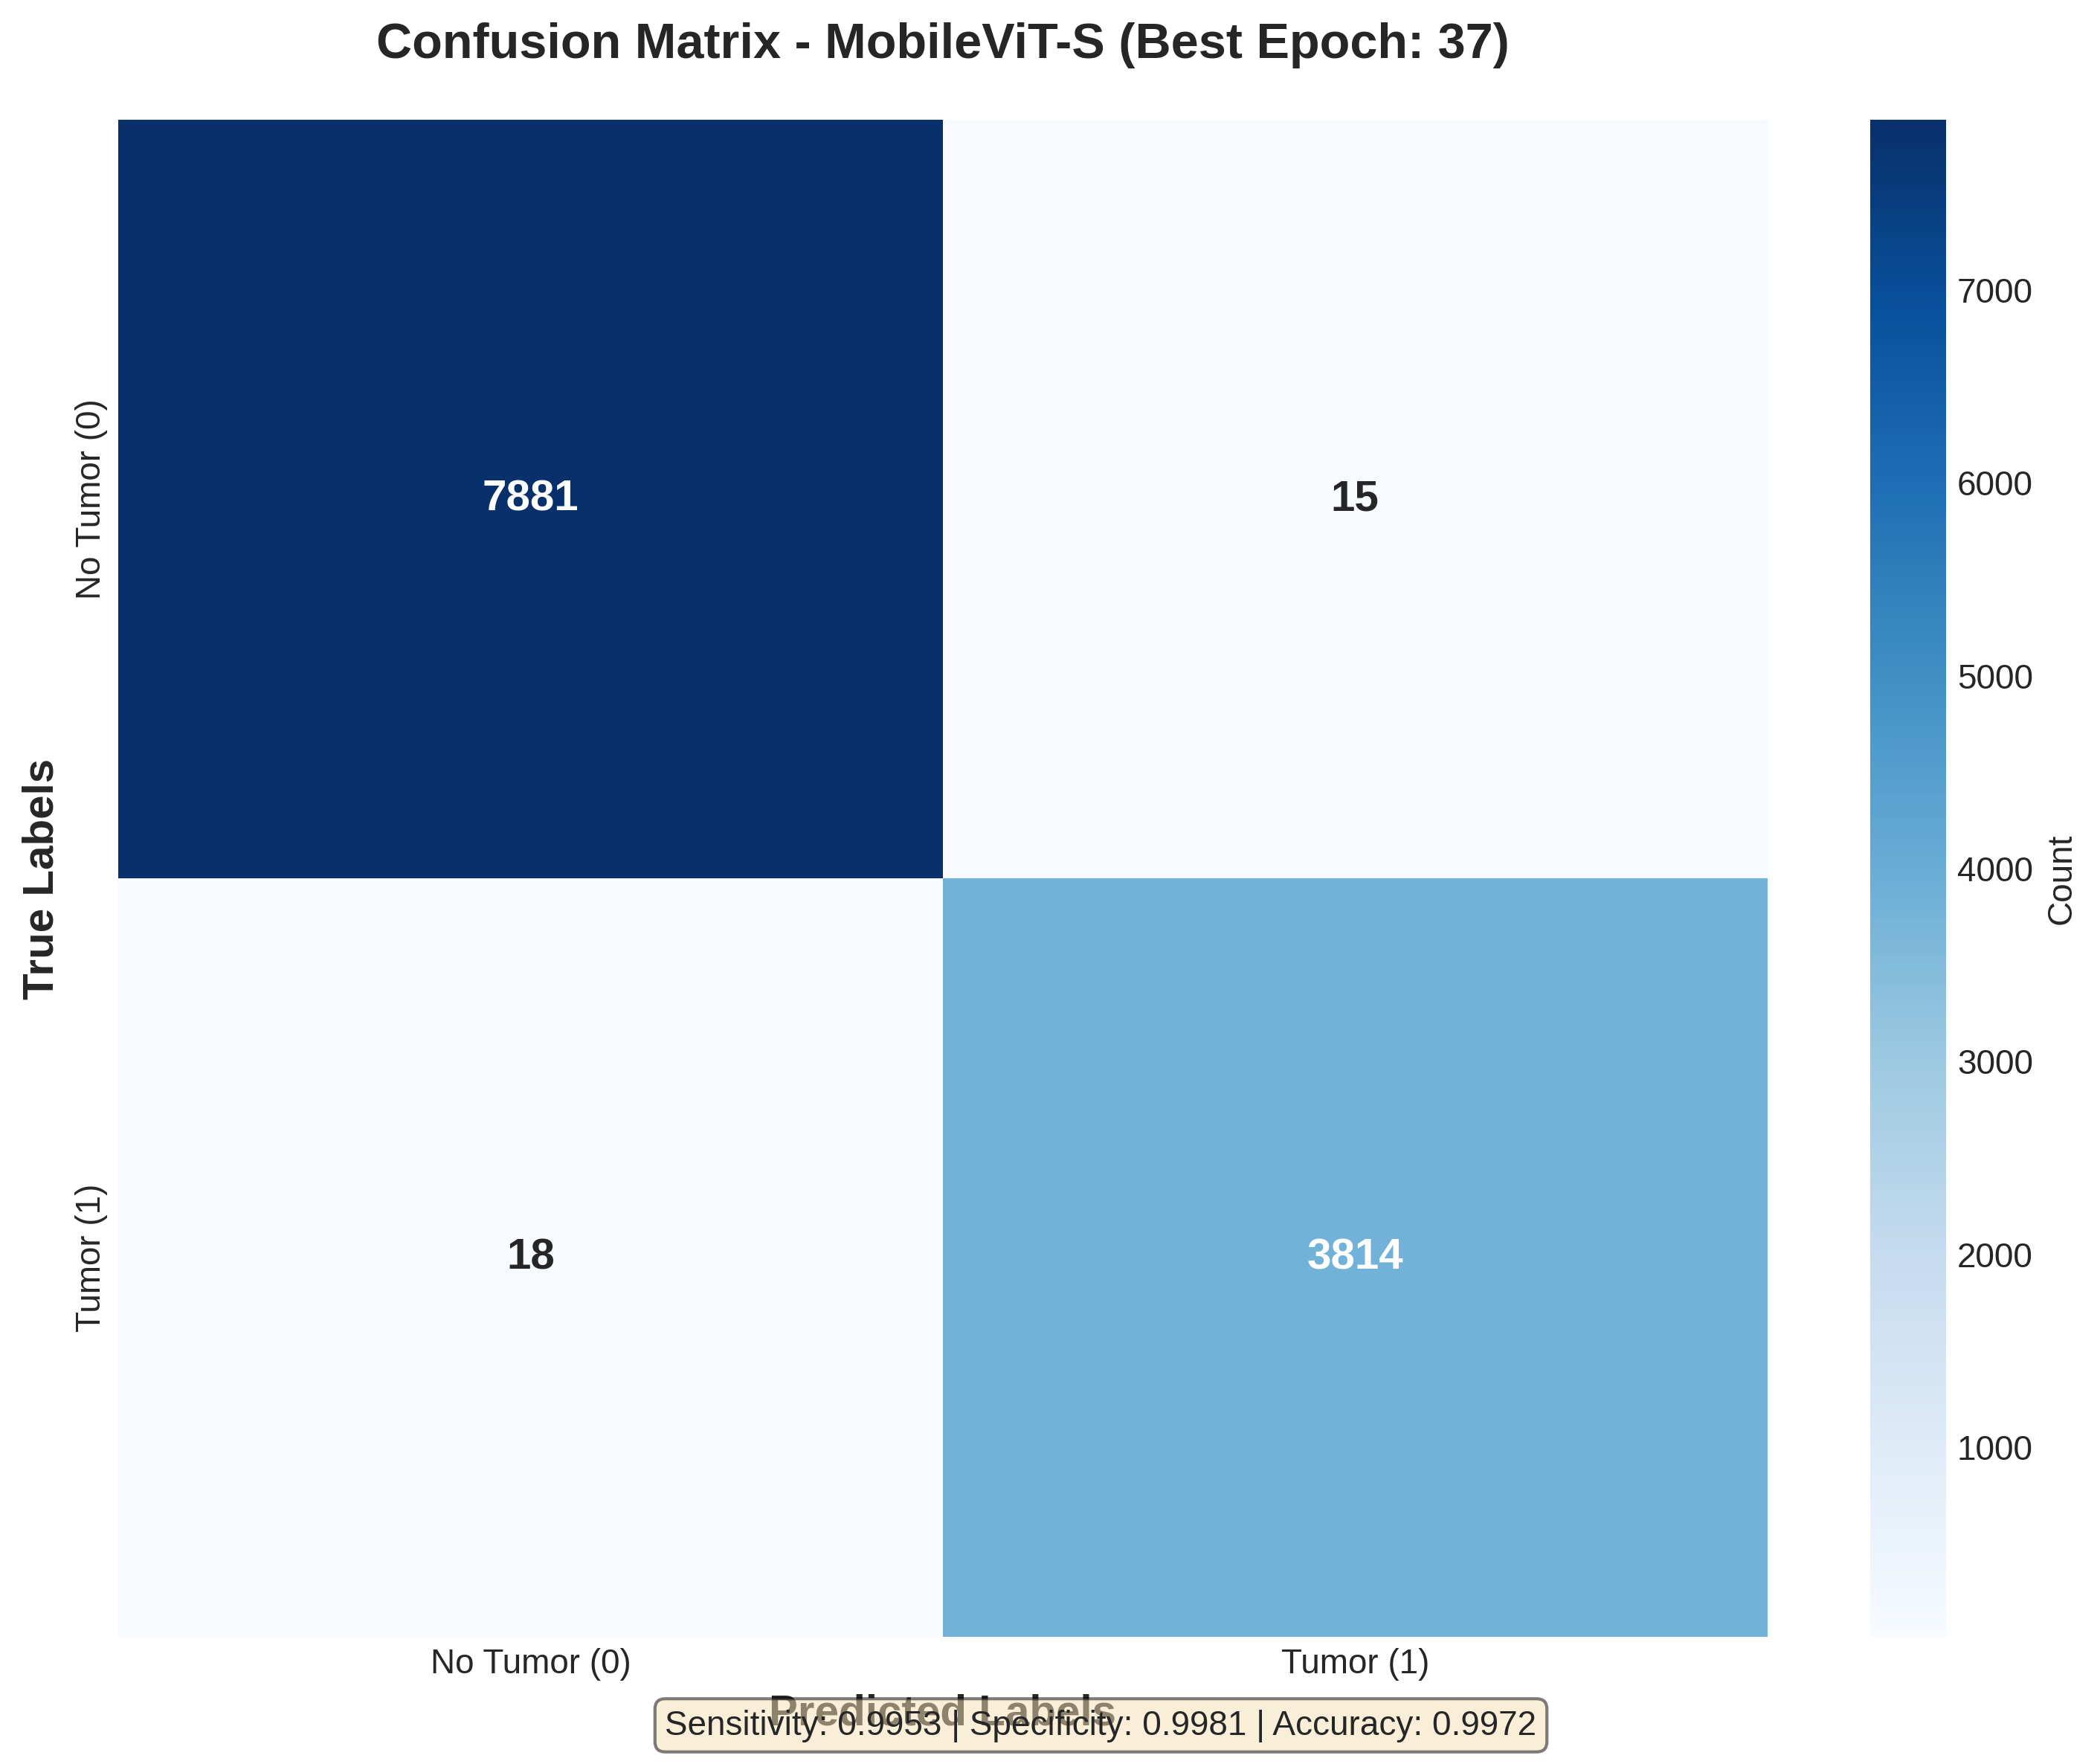

2️⃣  Generating Accuracy & Loss Curves (Combined)...
   ✓ Saved: 2_accuracy_loss_combined.png


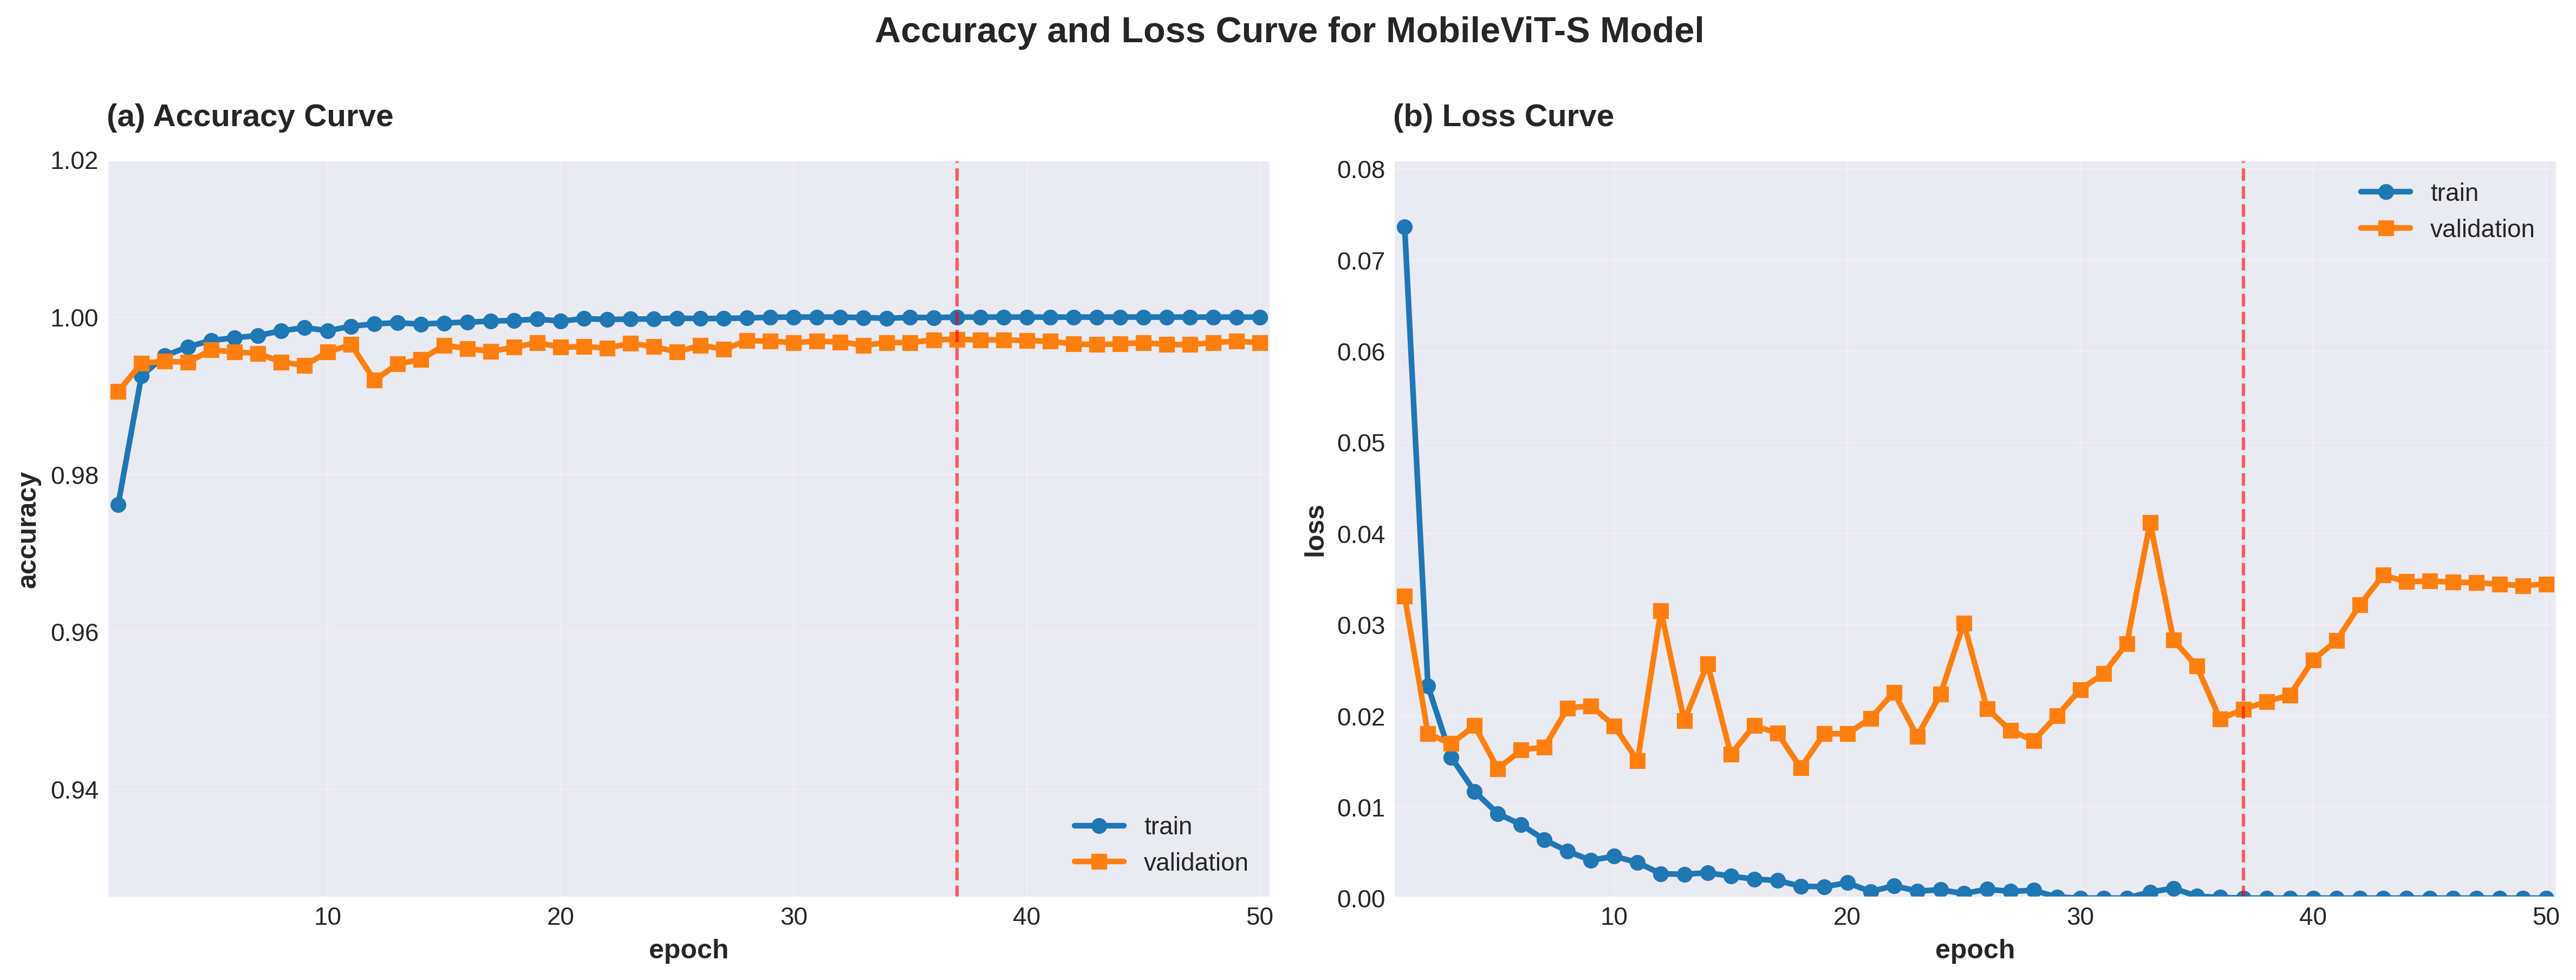

3️⃣  Generating F1-Score Curve...
   ✓ Saved: 3_f1_score_curve.png


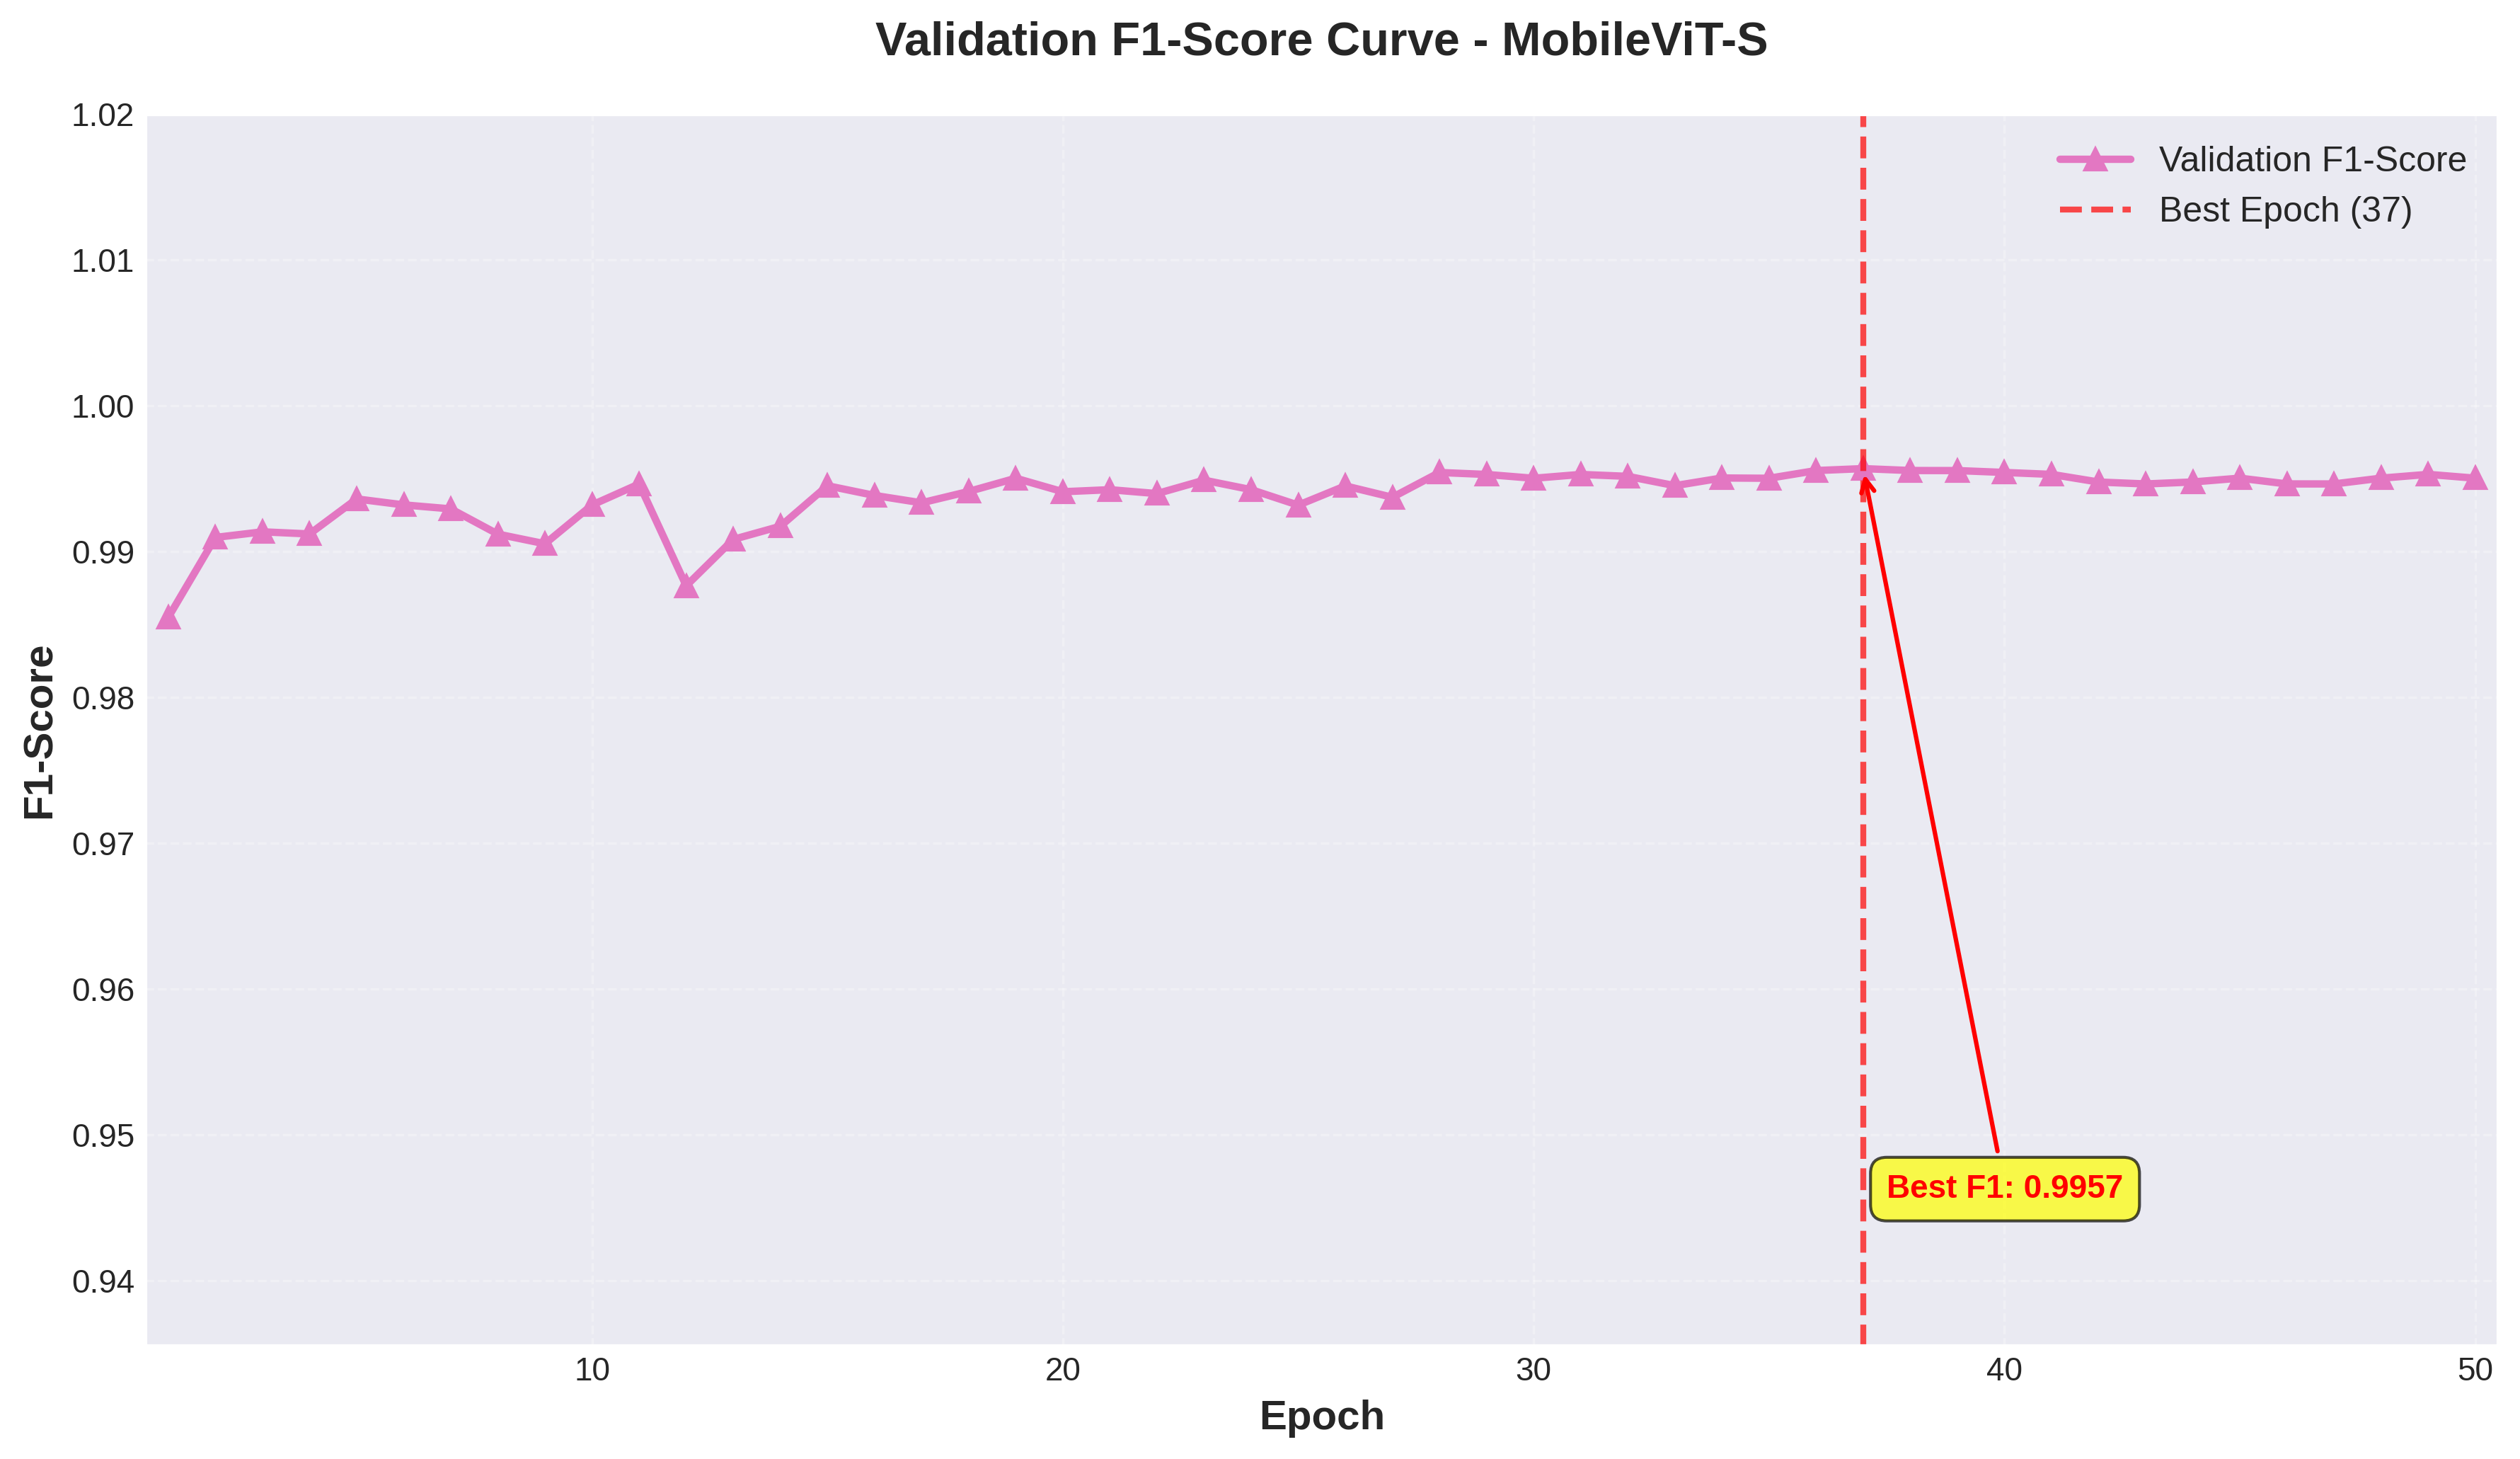

4️⃣  Generating Precision/Recall/F1 Combined Curve...
   ✓ Saved: 4_precision_recall_f1.png


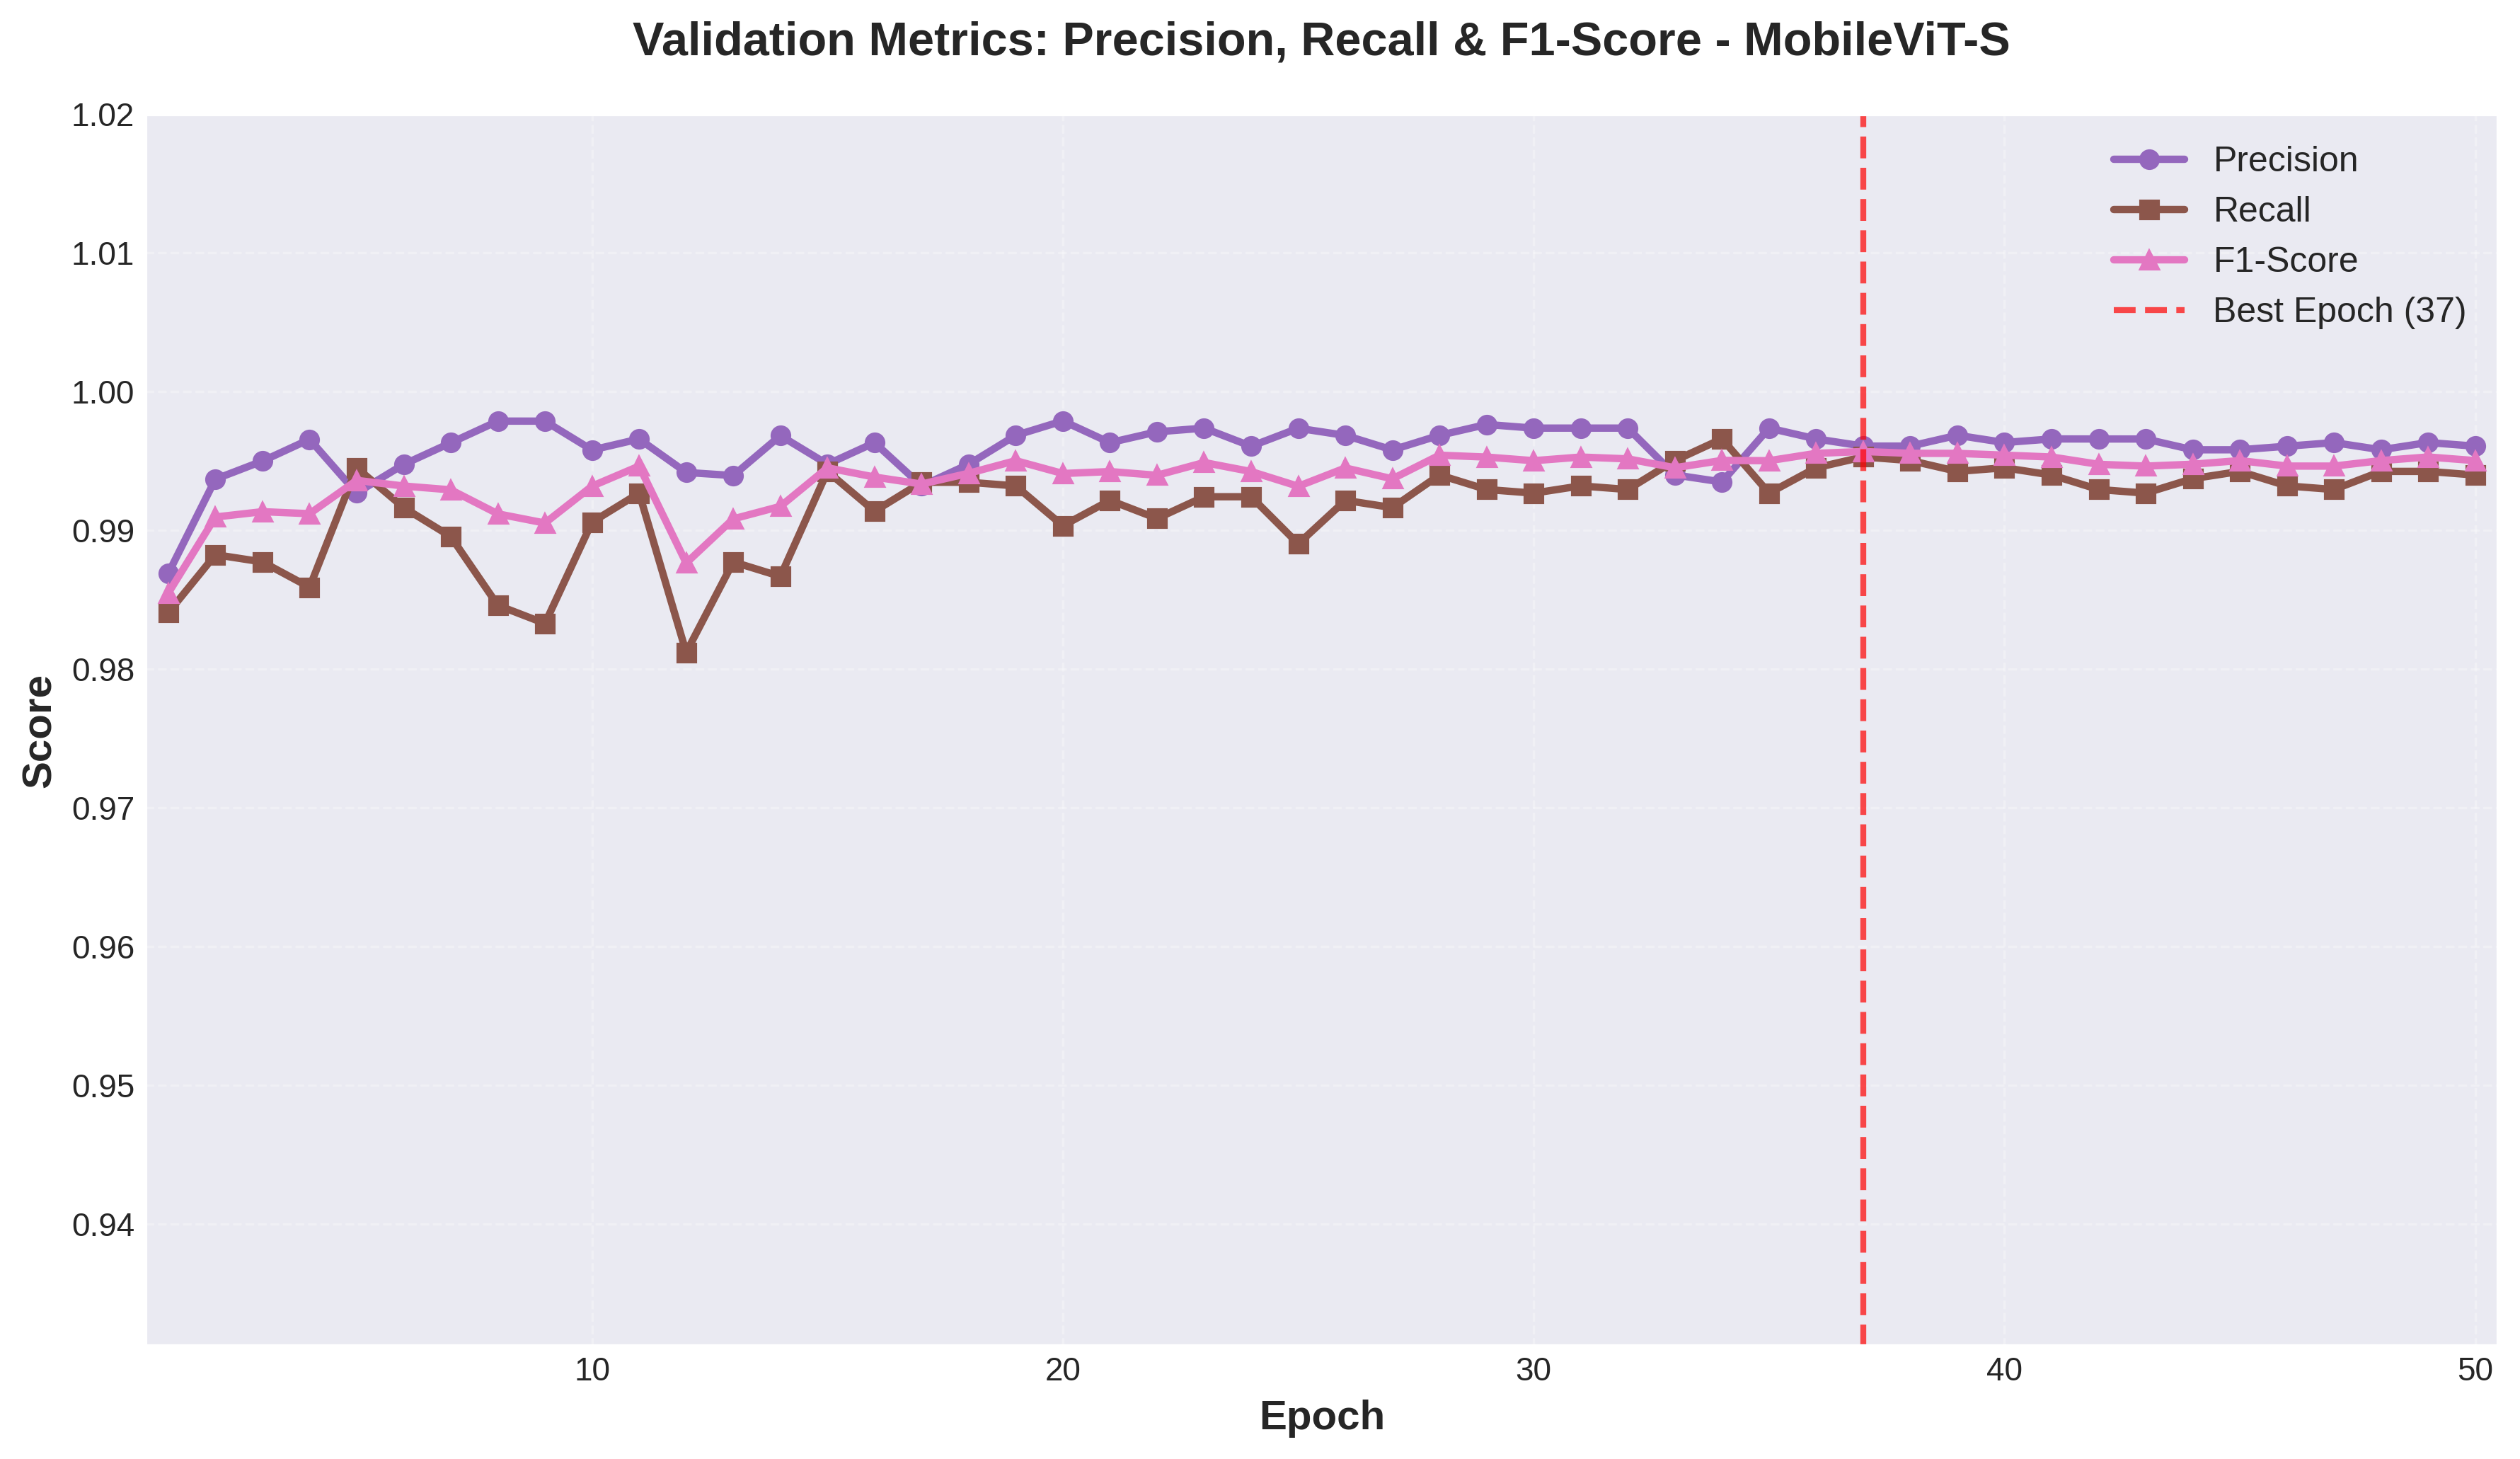

5️⃣  Generating ROC Curve...
   ✓ Saved: 5_roc_curve.png


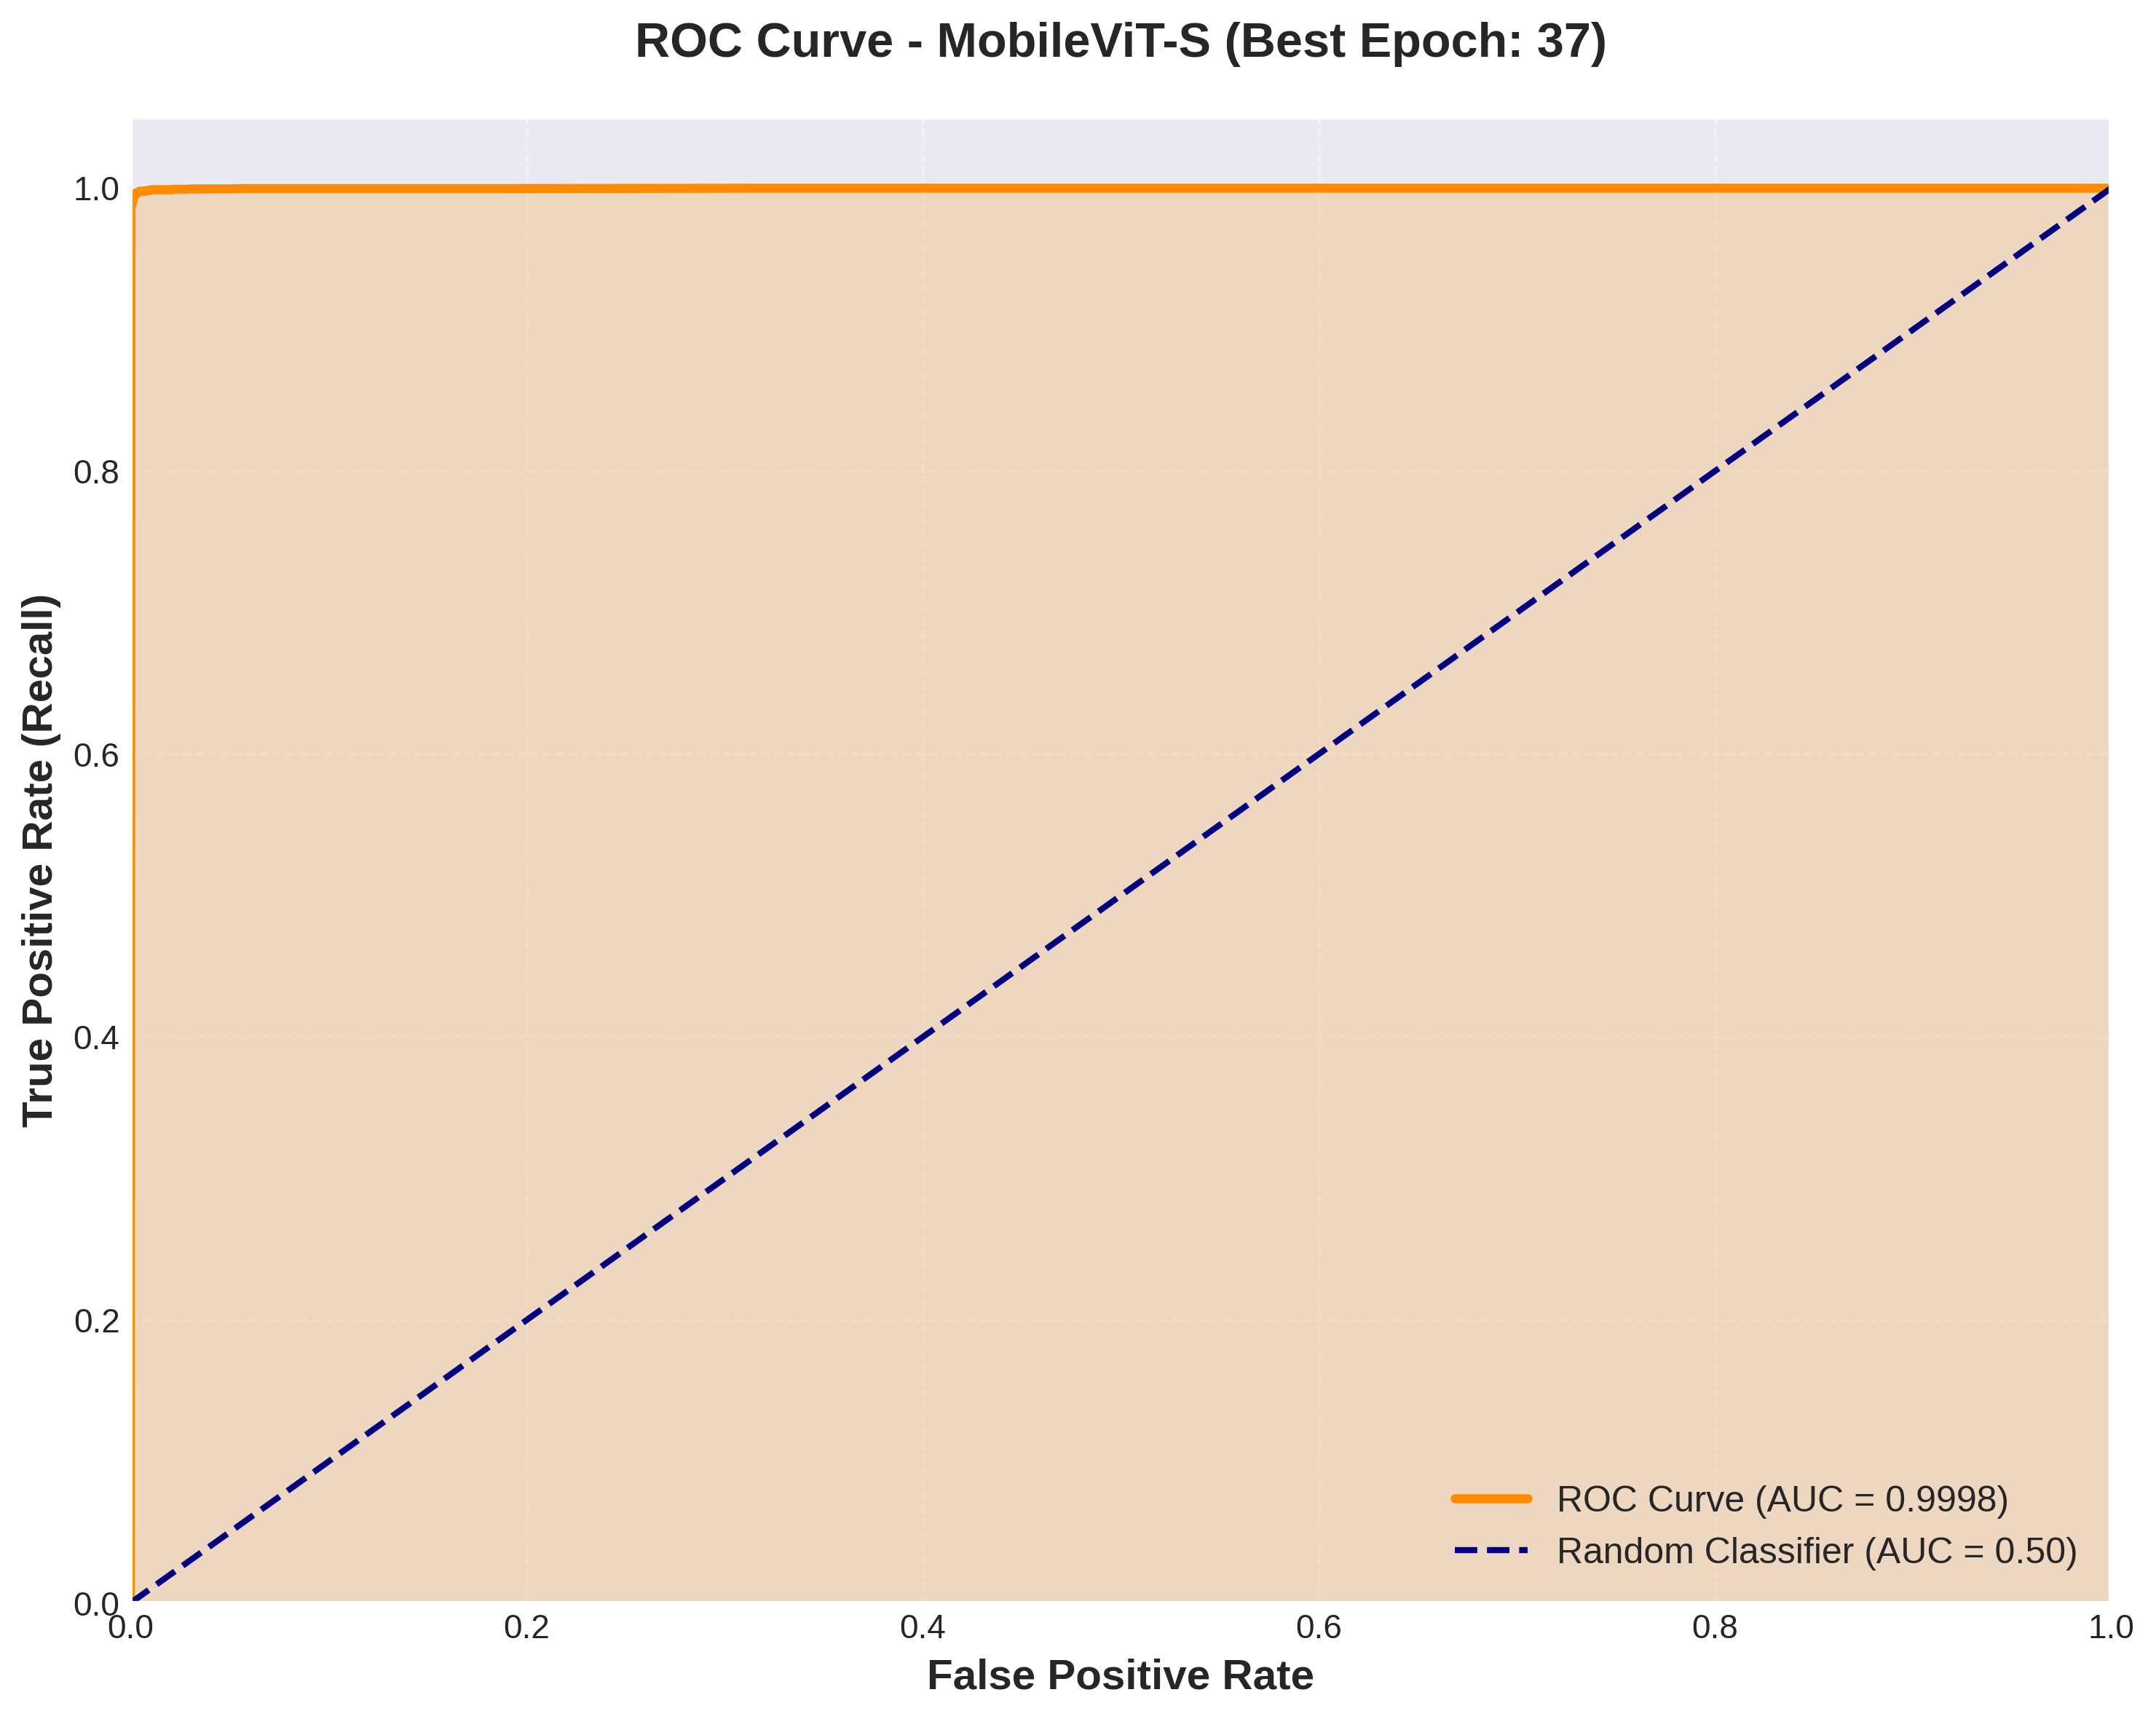

6️⃣  Generating Learning Rate Schedule...
   ✓ Saved: 6_learning_rate_schedule.png


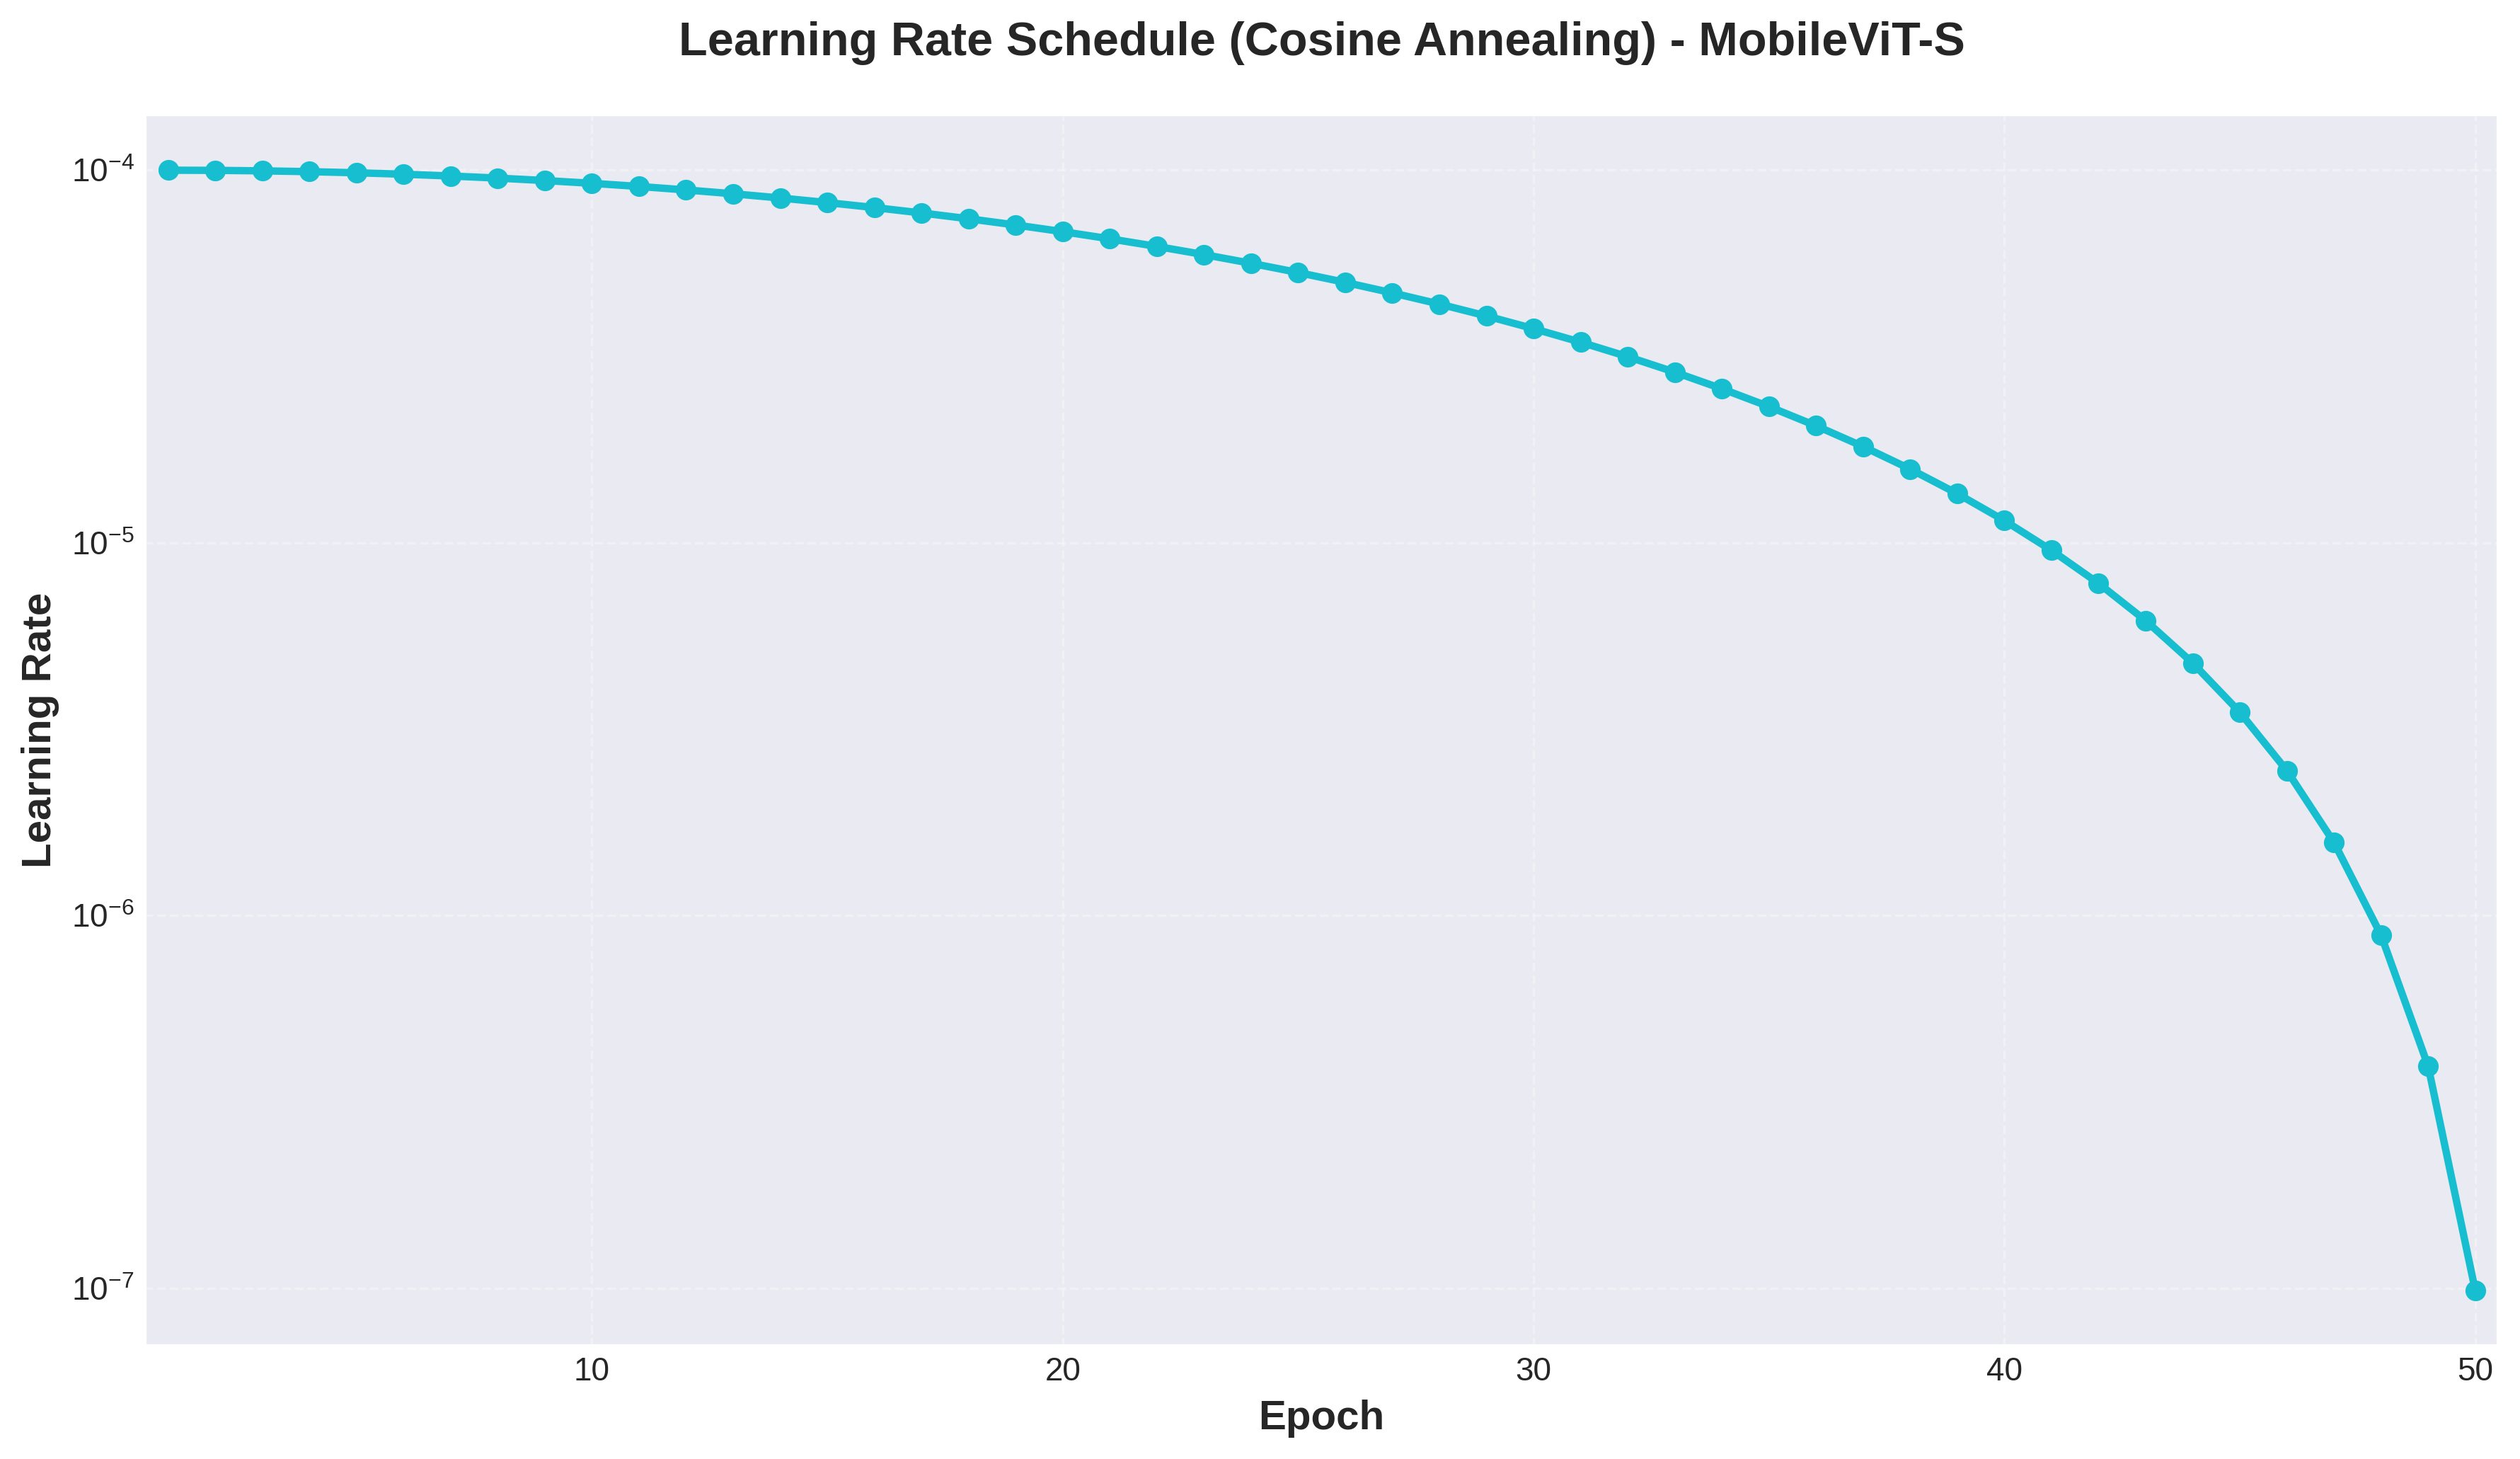

7️⃣  Creating Metrics Summary Table...
   ✓ Saved: 7_metrics_summary_table.png


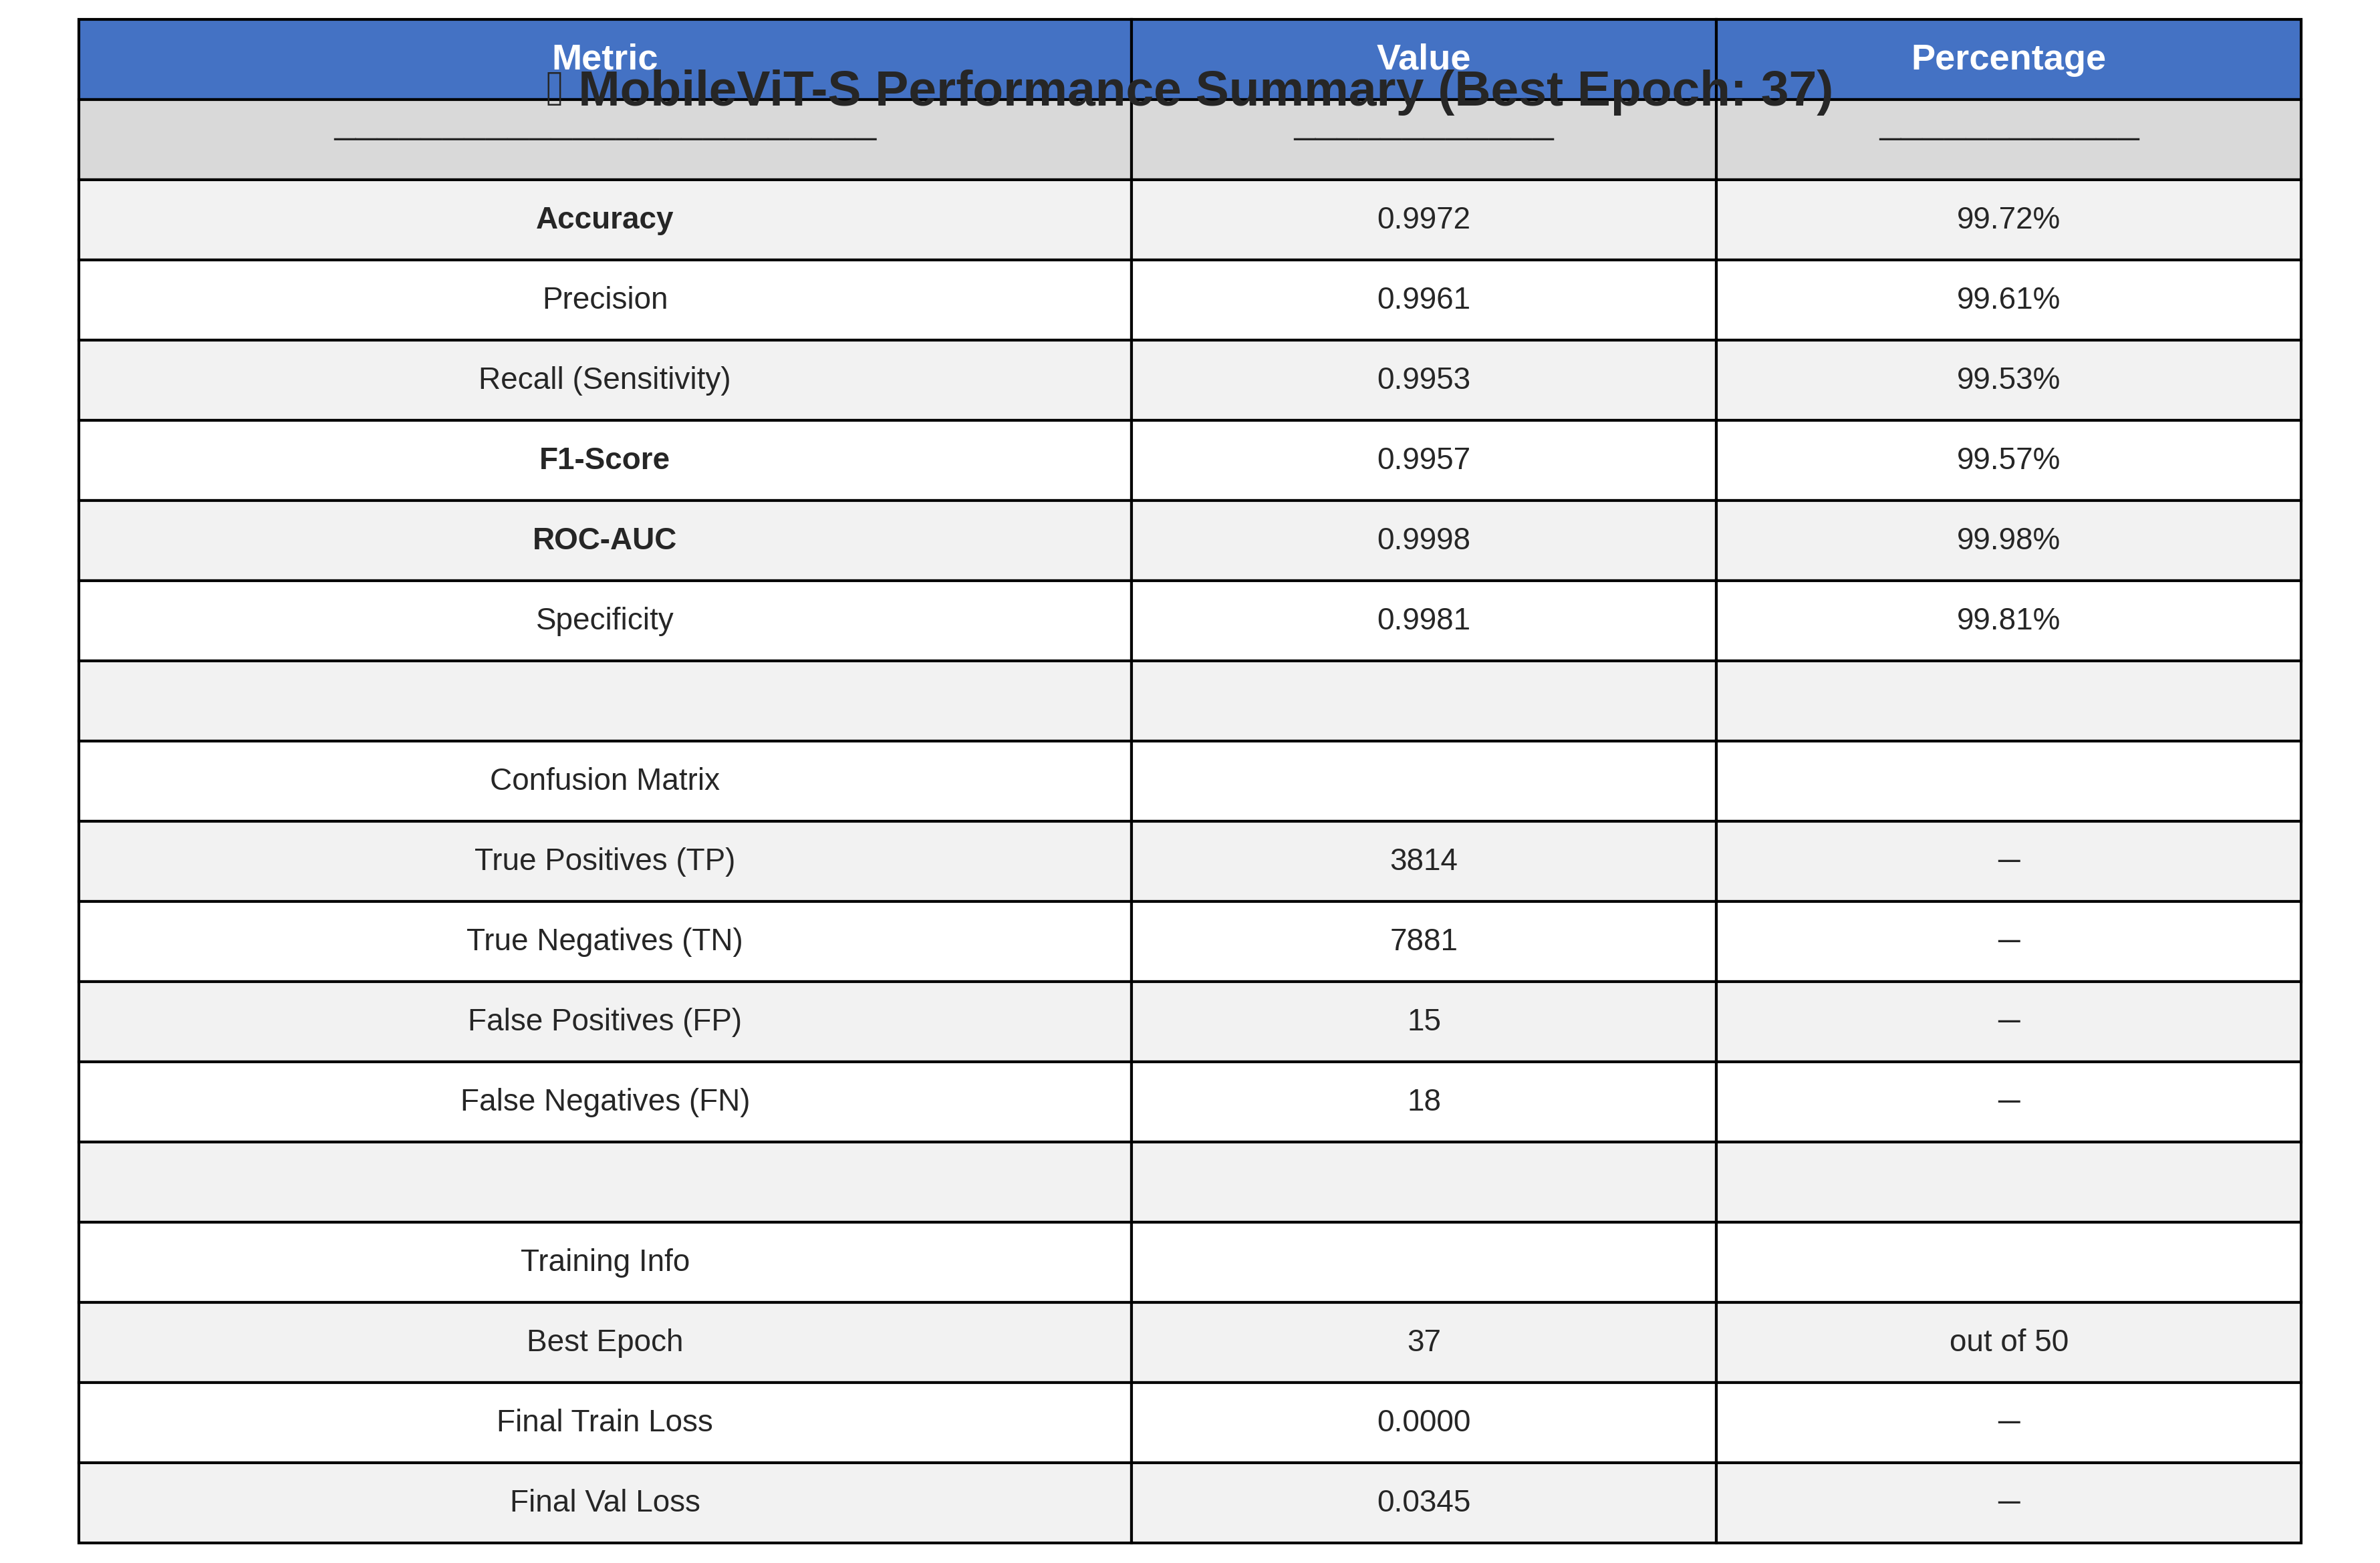


🎯 FINAL EVALUATION SUMMARY - MOBILEVIT-S

🏆 Best Model Performance (Epoch 37):
   ├─ Accuracy:  99.72%
   ├─ Precision: 99.61%
   ├─ Recall:    99.53%
   ├─ F1-Score:  99.57%
   └─ ROC-AUC:   99.98%

📊 Confusion Matrix:
   ├─ True Positives:  3814
   ├─ True Negatives:  7881
   ├─ False Positives: 15
   └─ False Negatives: 18

📈 Training Statistics:
   ├─ Total Epochs: 50
   ├─ Best Epoch: 37
   ├─ Final Train Loss: 0.0000
   └─ Final Val Loss: 0.0345

📁 Generated Visualization Files:
   ├─ 1_confusion_matrix.png
   ├─ 2_accuracy_loss_combined.png
   ├─ 3_f1_score_curve.png
   ├─ 4_precision_recall_f1.png
   ├─ 5_roc_curve.png
   ├─ 6_learning_rate_schedule.png
   └─ 7_metrics_summary_table.png

✅ ALL VISUALIZATIONS COMPLETED!
💡 Tip: Download images from Output tab or check /kaggle/working/


In [5]:
# ================================
# Cell 4: Comprehensive Evaluation & Visualization (MobileViT-S)
# Purpose: Generate all evaluation plots matching reference style
# Runtime: ~15-30 seconds
# ================================

print("="*60)
print("📊 GENERATING COMPREHENSIVE VISUALIZATIONS")
print("="*60)

# Set global plot parameters for high quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5

# Load saved data (if running separately)
try:
    history = np.load('/kaggle/working/training_history.npy', allow_pickle=True).item()
    best_metrics = np.load('/kaggle/working/best_metrics.npy', allow_pickle=True).item()
    best_val_probs = np.load('/kaggle/working/best_val_probs.npy', allow_pickle=True)
    best_val_targets = np.load('/kaggle/working/best_val_targets.npy', allow_pickle=True)
    print("✓ Loaded training data from saved files")
except:
    print("⚠️  Using data from current session")

# Get best epoch
best_epoch = np.argmax(history['val_f1']) + 1
best_val_f1 = max(history['val_f1'])

epochs_range = range(1, len(history['train_loss']) + 1)
max_epochs = len(history['train_loss'])

print(f"✓ Best epoch: {best_epoch} (F1: {best_val_f1:.4f})")
print(f"✓ Total epochs: {max_epochs}")


# ================================
# 1. CONFUSION MATRIX HEATMAP
# ================================
print("\n1️⃣  Generating Confusion Matrix...")
fig1, ax1 = plt.subplots(figsize=(10, 8))

cm = best_metrics['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Tumor (0)', 'Tumor (1)'],
            yticklabels=['No Tumor (0)', 'Tumor (1)'],
            ax=ax1, cbar_kws={'label': 'Count'}, 
            annot_kws={'size': 14, 'weight': 'bold'})

ax1.set_xlabel('Predicted Labels', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Labels', fontsize=14, fontweight='bold')
ax1.set_title(f'Confusion Matrix - MobileViT-S (Best Epoch: {best_epoch})', 
              fontsize=16, fontweight='bold', pad=20)

# Add metrics below
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

metrics_text = (f'Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f} | '
                f'Accuracy: {best_metrics["accuracy"]:.4f}')
plt.figtext(0.5, 0.02, metrics_text, ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/kaggle/working/1_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 1_confusion_matrix.png")
plt.show()
plt.close()


# ================================
# 2. ACCURACY & LOSS CURVES (SIDE-BY-SIDE)
# ================================
print("2️⃣  Generating Accuracy & Loss Curves (Combined)...")

fig2, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('white')

# -------- (a) Accuracy Curve --------
ax_acc.plot(epochs_range, history['train_acc'], 
            label='train', linewidth=2.5, color='#1f77b4', marker='o', markersize=6)
ax_acc.plot(epochs_range, history['val_acc'], 
            label='validation', linewidth=2.5, color='#ff7f0e', marker='s', markersize=6)

# Mark best epoch
ax_acc.axvline(x=best_epoch, color='red', linestyle='--', 
               linewidth=1.5, alpha=0.6)

ax_acc.set_xlabel('epoch', fontsize=12, fontweight='bold')
ax_acc.set_ylabel('accuracy', fontsize=12, fontweight='bold')
ax_acc.set_title('(a) Accuracy Curve', fontsize=14, fontweight='bold', 
                 loc='left', pad=15)
ax_acc.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax_acc.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax_acc.set_ylim([min(min(history['train_acc']), min(history['val_acc'])) - 0.05, 1.02])
ax_acc.set_xlim([0.5, max_epochs + 0.5])

# -------- (b) Loss Curve --------
ax_loss.plot(epochs_range, history['train_loss'], 
             label='train', linewidth=2.5, color='#1f77b4', marker='o', markersize=6)
ax_loss.plot(epochs_range, history['val_loss'], 
             label='validation', linewidth=2.5, color='#ff7f0e', marker='s', markersize=6)

# Mark best epoch
ax_loss.axvline(x=best_epoch, color='red', linestyle='--', 
                linewidth=1.5, alpha=0.6)

ax_loss.set_xlabel('epoch', fontsize=12, fontweight='bold')
ax_loss.set_ylabel('loss', fontsize=12, fontweight='bold')
ax_loss.set_title('(b) Loss Curve', fontsize=14, fontweight='bold', 
                  loc='left', pad=15)
ax_loss.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax_loss.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

max_loss = max(max(history['train_loss']), max(history['val_loss']))
ax_loss.set_ylim([0, max_loss * 1.1])
ax_loss.set_xlim([0.5, max_epochs + 0.5])

# Main title
plt.suptitle('Accuracy and Loss Curve for MobileViT-S Model', 
             fontsize=16, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('/kaggle/working/2_accuracy_loss_combined.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 2_accuracy_loss_combined.png")
plt.show()
plt.close()


# ================================
# 3. F1-SCORE CURVE
# ================================
print("3️⃣  Generating F1-Score Curve...")
fig3, ax3 = plt.subplots(figsize=(12, 7))

ax3.plot(epochs_range, history['val_f1'], 
         label='Validation F1-Score', marker='^', linewidth=2.5, 
         markersize=7, color='#e377c2')

# Mark best epoch
ax3.axvline(x=best_epoch, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')

# Annotate best F1
ax3.annotate(f'Best F1: {best_val_f1:.4f}', 
             xy=(best_epoch, best_val_f1), 
             xytext=(best_epoch + 0.5, best_val_f1 - 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax3.set_ylabel('F1-Score', fontsize=14, fontweight='bold')
ax3.set_title('Validation F1-Score Curve - MobileViT-S', 
              fontsize=16, fontweight='bold', pad=20)
ax3.legend(loc='best', fontsize=12, framealpha=0.9)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim([max(0, min(history['val_f1']) - 0.05), 1.02])
ax3.set_xlim([0.5, max_epochs + 0.5])

plt.tight_layout()
plt.savefig('/kaggle/working/3_f1_score_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 3_f1_score_curve.png")
plt.show()
plt.close()


# ================================
# 4. PRECISION, RECALL, F1 (COMBINED)
# ================================
print("4️⃣  Generating Precision/Recall/F1 Combined Curve...")
fig4, ax4 = plt.subplots(figsize=(12, 7))

ax4.plot(epochs_range, history['val_precision'], 
         label='Precision', marker='o', linewidth=2.5, markersize=6, 
         color='#9467bd')
ax4.plot(epochs_range, history['val_recall'], 
         label='Recall', marker='s', linewidth=2.5, markersize=6, 
         color='#8c564b')
ax4.plot(epochs_range, history['val_f1'], 
         label='F1-Score', marker='^', linewidth=2.5, markersize=6, 
         color='#e377c2')

# Mark best epoch
ax4.axvline(x=best_epoch, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')

ax4.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax4.set_ylabel('Score', fontsize=14, fontweight='bold')
ax4.set_title('Validation Metrics: Precision, Recall & F1-Score - MobileViT-S', 
              fontsize=16, fontweight='bold', pad=20)
ax4.legend(loc='best', fontsize=12, framealpha=0.9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim([max(0, min(min(history['val_precision']), min(history['val_recall']), 
                          min(history['val_f1'])) - 0.05), 1.02])
ax4.set_xlim([0.5, max_epochs + 0.5])

plt.tight_layout()
plt.savefig('/kaggle/working/4_precision_recall_f1.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 4_precision_recall_f1.png")
plt.show()
plt.close()


# ================================
# 5. ROC CURVE WITH AUC
# ================================
print("5️⃣  Generating ROC Curve...")
fig5, ax5 = plt.subplots(figsize=(10, 8))

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(best_val_targets, best_val_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
ax5.plot(fpr, tpr, color='darkorange', linewidth=3, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax5.plot([0, 1], [0, 1], color='navy', linewidth=2, 
         linestyle='--', label='Random Classifier (AUC = 0.50)')
ax5.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

ax5.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax5.set_ylabel('True Positive Rate (Recall)', fontsize=14, fontweight='bold')
ax5.set_title(f'ROC Curve - MobileViT-S (Best Epoch: {best_epoch})', 
              fontsize=16, fontweight='bold', pad=20)
ax5.legend(loc='lower right', fontsize=12, framealpha=0.9)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('/kaggle/working/5_roc_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 5_roc_curve.png")
plt.show()
plt.close()


# ================================
# 6. LEARNING RATE SCHEDULE
# ================================
print("6️⃣  Generating Learning Rate Schedule...")
fig6, ax6 = plt.subplots(figsize=(12, 7))

ax6.plot(epochs_range, history['learning_rates'], 
         marker='o', linewidth=2.5, markersize=6, color='#17becf')

ax6.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax6.set_ylabel('Learning Rate', fontsize=14, fontweight='bold')
ax6.set_title('Learning Rate Schedule (Cosine Annealing) - MobileViT-S', 
              fontsize=16, fontweight='bold', pad=20)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_yscale('log')
ax6.set_xlim([0.5, max_epochs + 0.5])

plt.tight_layout()
plt.savefig('/kaggle/working/6_learning_rate_schedule.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 6_learning_rate_schedule.png")
plt.show()
plt.close()


# ================================
# 7. METRICS SUMMARY TABLE
# ================================
print("7️⃣  Creating Metrics Summary Table...")
fig7, ax7 = plt.subplots(figsize=(12, 8))
ax7.axis('off')

# Create table data
table_data = [
    ['Metric', 'Value', 'Percentage'],
    ['─' * 25, '─' * 12, '─' * 12],
    ['Accuracy', f'{best_metrics["accuracy"]:.4f}', f'{best_metrics["accuracy"]*100:.2f}%'],
    ['Precision', f'{best_metrics["precision"]:.4f}', f'{best_metrics["precision"]*100:.2f}%'],
    ['Recall (Sensitivity)', f'{best_metrics["recall"]:.4f}', f'{best_metrics["recall"]*100:.2f}%'],
    ['F1-Score', f'{best_metrics["f1_score"]:.4f}', f'{best_metrics["f1_score"]*100:.2f}%'],
    ['ROC-AUC', f'{roc_auc:.4f}', f'{roc_auc*100:.2f}%'],
    ['Specificity', f'{specificity:.4f}', f'{specificity*100:.2f}%'],
    ['', '', ''],
    ['Confusion Matrix', '', ''],
    ['True Positives (TP)', f'{tp}', '─'],
    ['True Negatives (TN)', f'{tn}', '─'],
    ['False Positives (FP)', f'{fp}', '─'],
    ['False Negatives (FN)', f'{fn}', '─'],
    ['', '', ''],
    ['Training Info', '', ''],
    ['Best Epoch', f'{best_epoch}', f'out of {max_epochs}'],
    ['Final Train Loss', f'{history["train_loss"][-1]:.4f}', '─'],
    ['Final Val Loss', f'{history["val_loss"][-1]:.4f}', '─'],
]

table = ax7.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.45, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white', size=13)

# Style rows
for i in range(1, len(table_data)):
    if '─' in table_data[i][0]:  # Separator rows
        for j in range(3):
            table[(i, j)].set_facecolor('#D9D9D9')
    elif i % 2 == 0:
        for j in range(3):
            table[(i, j)].set_facecolor('#F2F2F2')
    
    # Bold important metrics
    if i in [2, 5, 6]:  # Accuracy, F1, AUC
        table[(i, 0)].set_text_props(weight='bold')

ax7.set_title(f'📋 MobileViT-S Performance Summary (Best Epoch: {best_epoch})', 
              fontsize=18, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('/kaggle/working/7_metrics_summary_table.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 7_metrics_summary_table.png")
plt.show()
plt.close()


# ================================
# FINAL CONSOLE SUMMARY
# ================================
print("\n" + "="*60)
print("🎯 FINAL EVALUATION SUMMARY - MOBILEVIT-S")
print("="*60)
print(f"\n🏆 Best Model Performance (Epoch {best_epoch}):")
print(f"   ├─ Accuracy:  {best_metrics['accuracy']*100:.2f}%")
print(f"   ├─ Precision: {best_metrics['precision']*100:.2f}%")
print(f"   ├─ Recall:    {best_metrics['recall']*100:.2f}%")
print(f"   ├─ F1-Score:  {best_metrics['f1_score']*100:.2f}%")
print(f"   └─ ROC-AUC:   {roc_auc*100:.2f}%")

print(f"\n📊 Confusion Matrix:")
print(f"   ├─ True Positives:  {tp}")
print(f"   ├─ True Negatives:  {tn}")
print(f"   ├─ False Positives: {fp}")
print(f"   └─ False Negatives: {fn}")

print(f"\n📈 Training Statistics:")
print(f"   ├─ Total Epochs: {max_epochs}")
print(f"   ├─ Best Epoch: {best_epoch}")
print(f"   ├─ Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   └─ Final Val Loss: {history['val_loss'][-1]:.4f}")

print("\n📁 Generated Visualization Files:")
print("   ├─ 1_confusion_matrix.png")
print("   ├─ 2_accuracy_loss_combined.png")
print("   ├─ 3_f1_score_curve.png")
print("   ├─ 4_precision_recall_f1.png")
print("   ├─ 5_roc_curve.png")
print("   ├─ 6_learning_rate_schedule.png")
print("   └─ 7_metrics_summary_table.png")

print("\n" + "="*60)
print("✅ ALL VISUALIZATIONS COMPLETED!")
print("="*60)
print("💡 Tip: Download images from Output tab or check /kaggle/working/")
print("="*60)